In [1]:
# Run once if needed
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels requests

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import os, warnings, itertools, time

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import t as t_dist, randint, uniform
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 5), "figure.dpi": 150,
    "axes.titlesize": 12, "axes.labelsize": 10, "legend.fontsize": 9,
})

## 1. Load RKI data

In [3]:
# --- Load RKI data directly from the official repository ---
url = (
    "https://media.githubusercontent.com/media/robert-koch-institut/"
    "SARS-CoV-2-Infektionen_in_Deutschland/main/"
    "Aktuell_Deutschland_SarsCov2_Infektionen.csv"
)

df = pd.read_csv(url, low_memory=False)

print("Raw data shape:", df.shape)
df.head()

Raw data shape: (7758490, 12)


,IdLandkreis,Altersgruppe,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen
0,1001,A15-A34,M,2020-10-28,2020-01-19,1,0,-9,0,1,0,1
1,1001,A15-A34,M,2020-03-19,2020-03-13,1,0,-9,0,1,0,1
2,1001,A15-A34,M,2020-03-21,2020-03-13,1,0,-9,0,1,0,1
3,1001,A35-A59,M,2020-03-14,2020-03-16,1,0,-9,0,1,0,1
4,1001,A15-A34,M,2020-03-19,2020-03-16,1,0,-9,0,1,0,1


In [4]:
df["Meldedatum"] = pd.to_datetime(df["Meldedatum"])
df_relevant = df.drop(columns=["NeuerFall", "NeuerTodesfall", "NeuGenesen",
                                "AnzahlGenesen", "AnzahlTodesfall"])
df_grouped = df_relevant.groupby("Meldedatum")[["AnzahlFall"]].sum()

min_date = "2020-04-01"
max_date = "2026-03-31"
date_idx = pd.date_range(min_date, max_date)

df_grouped_filled = df_grouped.reindex(date_idx, fill_value=0).reset_index(names="Meldedatum")
df_grouped_filled["logAnzahlFall"] = np.log1p(df_grouped_filled["AnzahlFall"])

print(f"Series: {len(df_grouped_filled)} days, {min_date} to {max_date}")
df_grouped_filled.head()

Series: 2191 days, 2020-04-01 to 2026-03-31


,Meldedatum,AnzahlFall,logAnzahlFall
0,2020-04-01,6257,8.741616
1,2020-04-02,6542,8.786151
2,2020-04-03,6182,8.729559
3,2020-04-04,4340,8.375860
4,2020-04-05,2532,7.837160


## 2. Covariates

- **Age-group shares** (daily proportions from RKI, lagged 1 day)
- **Daily mean temperature** from Open-Meteo (Berlin), lagged 1 day
- **Monday dummy** (deterministic, unlagged)

In [5]:
# --- Age-group shares ---
df_age = (
    df_relevant[df_relevant["Altersgruppe"] != "unbekannt"]
    .groupby(["Meldedatum", "Altersgruppe"])["AnzahlFall"]
    .sum().unstack(fill_value=0)
    .reindex(pd.date_range(min_date, max_date), fill_value=0)
)
df_props = df_age.div(df_age.sum(axis=1), axis=0).fillna(0)

reference_group = df_props.columns[0]
df_props_no_ref = df_props.drop(columns=reference_group)
print(f"Reference group dropped: {reference_group}")

df_props_lagged = df_props_no_ref.shift(1)

df_grouped_filled = df_grouped_filled.merge(
    df_props_lagged.reset_index(names="Meldedatum"),
    on="Meldedatum", how="left"
)
age_cols = df_props_no_ref.columns.tolist()
print(f"Age share columns ({len(age_cols)}): {age_cols}")

Reference group dropped: A00-A04
Age share columns (5): ['A05-A14', 'A15-A34', 'A35-A59', 'A60-A79', 'A80+']


In [6]:
# --- Temperature from Open-Meteo (always fetch fresh) ---
print("Downloading temperature from Open-Meteo ...")
params = {
    "latitude": 52.5244, "longitude": 13.4105,
    "start_date": "2020-04-01", "end_date": "2026-03-31",
    "daily": "temperature_2m_mean", "timezone": "Europe/Berlin",
}
resp = requests.get("https://archive-api.open-meteo.com/v1/archive",
                    params=params, timeout=120)
resp.raise_for_status()
js = resp.json()
temp = pd.DataFrame({
    "Meldedatum": pd.to_datetime(js["daily"]["time"]),
    "temperature": js["daily"]["temperature_2m_mean"],
})
temp.to_csv("weather_germany.csv", index=False)
print(f"Saved to weather_germany.csv")

df_grouped_filled = df_grouped_filled.merge(temp, on="Meldedatum", how="left")
df_grouped_filled["temperature"] = df_grouped_filled["temperature"].interpolate(limit_direction="both")
print("Temperature added:", "temperature" in df_grouped_filled.columns)

Saved to weather_germany.csv
Temperature added: True


In [7]:
# Monday dummy (deterministic -- known in advance, no lagging needed)
df_grouped_filled["is_monday"] = (df_grouped_filled["Meldedatum"].dt.dayofweek == 0).astype(int)

# Lagged temperature (1 day) for the linear ARX models
df_grouped_filled["temp_lag"] = df_grouped_filled["temperature"].shift(1)

df_grouped_filled[["Meldedatum","logAnzahlFall","temperature","temp_lag","is_monday"]].tail()

,Meldedatum,logAnzahlFall,temperature,temp_lag,is_monday
2186,2026-03-27,3.688879,3.4,4.4,0
2187,2026-03-28,1.791759,4.8,3.4,0
2188,2026-03-29,2.197225,5.6,4.8,0
2189,2026-03-30,4.615121,5.2,5.6,1
2190,2026-03-31,3.850148,5.0,5.2,0


## 3. Part (a): ACF/PACF and BIC lag selection

The ACF shows strong weekly periodicity (lag 7 spike), motivating **AR(7)** as
the baseline. BIC is evaluated over p = 1, ..., 10.

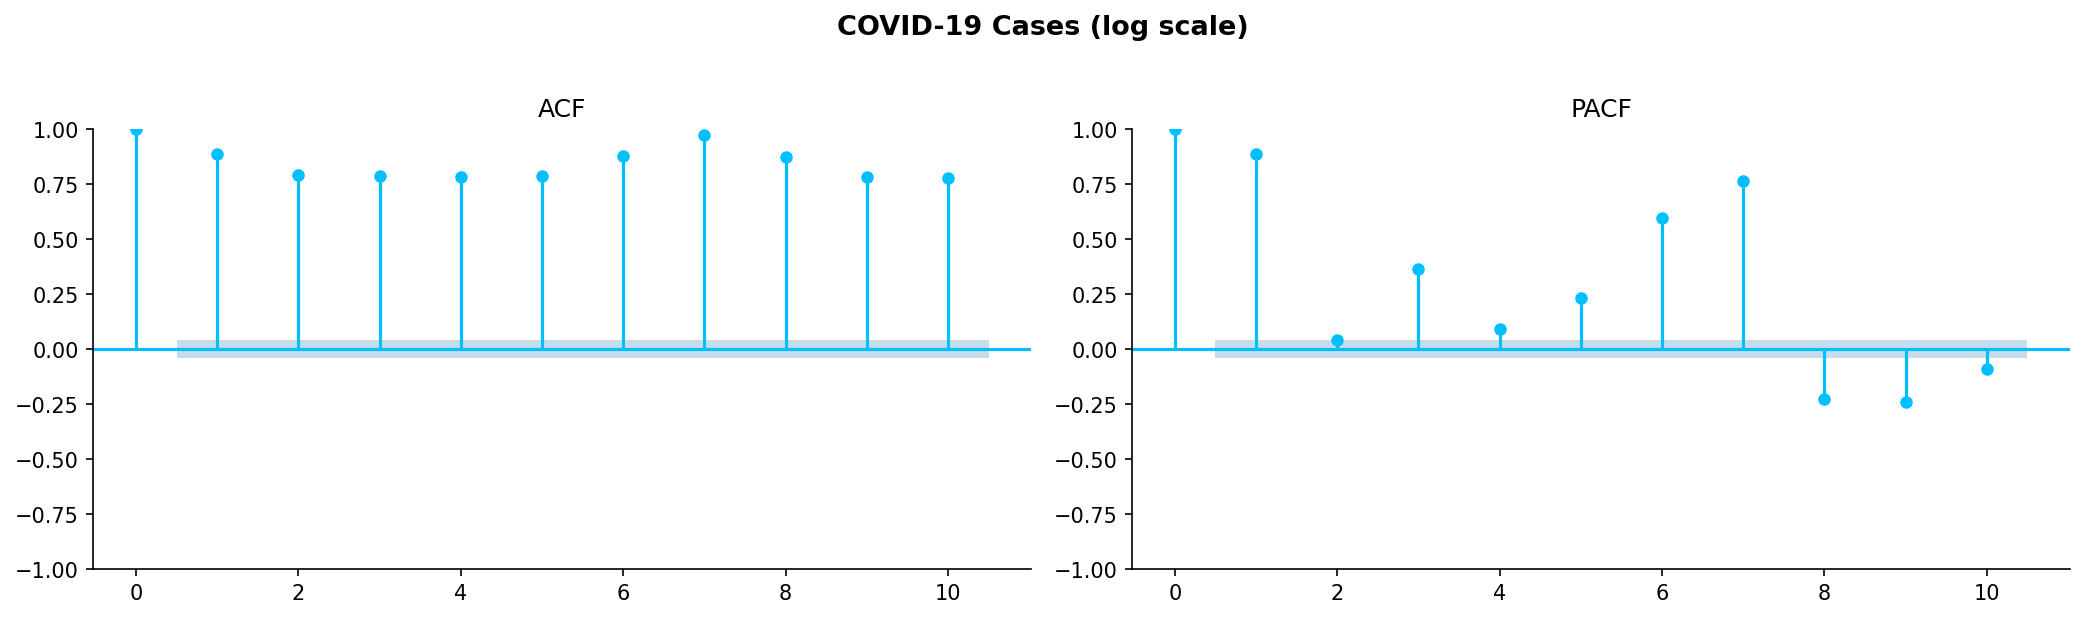

In [8]:
series = df_grouped_filled["logAnzahlFall"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=10, ax=axes[0], color="deepskyblue",
         vlines_kwargs={"colors":"deepskyblue"}, alpha=0.05, bartlett_confint=False)
axes[0].set_title("ACF"); axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)

plot_pacf(series, lags=10, ax=axes[1], method="ywm", color="deepskyblue",
          vlines_kwargs={"colors":"deepskyblue"}, alpha=0.05)
axes[1].set_title("PACF"); axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
plt.suptitle("COVID-19 Cases (log scale)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

BIC minimum: p = 10


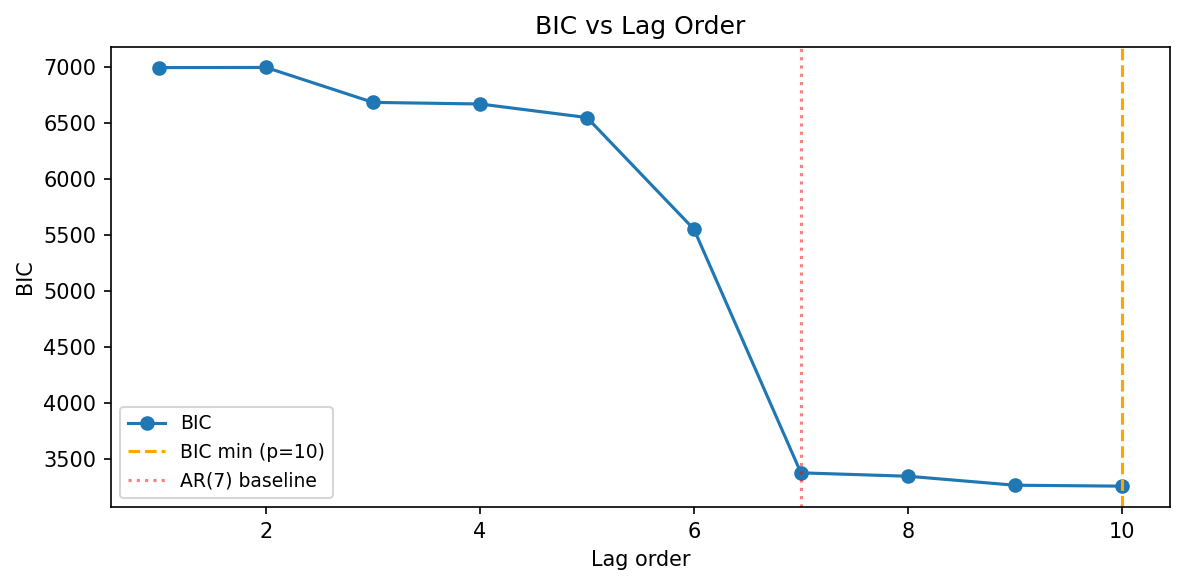

In [9]:
MAX_LAG = 10
bic_list = []

for p in range(1, MAX_LAG + 1):
    model = AutoReg(df_grouped_filled["logAnzahlFall"].dropna(),
                    lags=p, old_names=False).fit()
    bic_list.append({"p": p, "BIC": model.bic})

bic_df = pd.DataFrame(bic_list)
p_bic  = int(bic_df.loc[bic_df["BIC"].idxmin(), "p"])
p_fall = p_bic
print(f"BIC minimum: p = {p_bic}")

plt.figure(figsize=(8, 4))
plt.plot(bic_df["p"], bic_df["BIC"], "o-", label="BIC")
plt.axvline(p_bic, color="orange", ls="--", label=f"BIC min (p={p_bic})")
plt.axvline(7, color="red", ls=":", alpha=0.5, label="AR(7) baseline")
plt.xlabel("Lag order"); plt.ylabel("BIC")
plt.title("BIC vs Lag Order"); plt.legend(); plt.tight_layout(); plt.show()

## 4. Train / test split (80 / 20)

In [10]:
n_total  = len(df_grouped_filled)
n_train  = int(n_total * 0.8)
n_test   = n_total - n_train
n_train0 = n_train
WINDOW   = n_train

train_df = df_grouped_filled.iloc[:n_train].copy()
test_df  = df_grouped_filled.iloc[n_train:].copy()

train_data = train_df["logAnzahlFall"].dropna()
test_data  = test_df["logAnzahlFall"].dropna()

print(f"Train : {n_train} rows ({train_df['Meldedatum'].iloc[0].date()} to {train_df['Meldedatum'].iloc[-1].date()})")
print(f"Test  : {n_test} rows ({test_df['Meldedatum'].iloc[0].date()} to {test_df['Meldedatum'].iloc[-1].date()})")
print(f"Rolling window size: {WINDOW}")

forecast_records = {}

Train : 1752 rows (2020-04-01 to 2025-01-16)
Test  : 439 rows (2025-01-17 to 2026-03-31)
Rolling window size: 1752


## 5. Helper: back-transformation

All evaluation uses **original case counts** via `expm1`.

In [11]:
def to_level(x):
    return np.expm1(np.asarray(x, dtype=float))

def rmsfe_level(actual_log, pred_log):
    a = to_level(actual_log)
    f = to_level(pred_log)
    mask = np.isfinite(a) & np.isfinite(f)
    return float(np.sqrt(np.mean((a[mask] - f[mask])**2)))

## 6. Part (b): Fixed-origin AR forecasts

AR(7) and AR(p_bic) estimated once on training data.
**One-step-ahead** forecasts using actual past values (frozen coefficients).

AR(7) fixed  RMSFE(level): 223.73
AR(10) fixed  RMSFE(level): 199.73


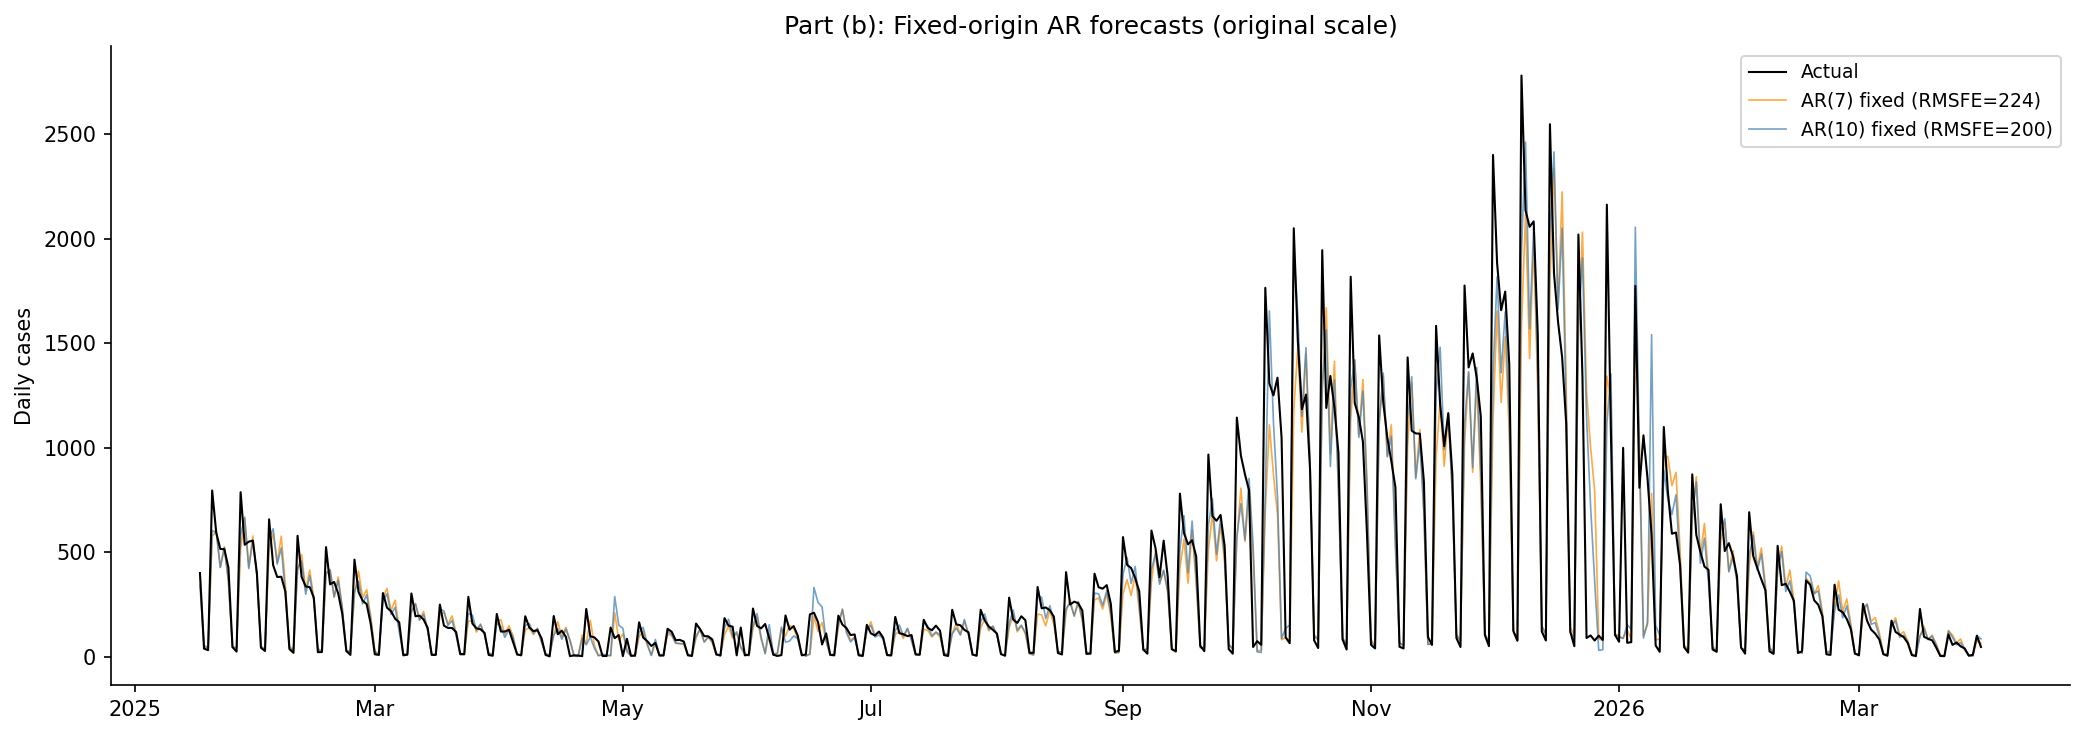

In [12]:
# --- AR(7) fixed-origin, one-step-ahead ---
model_ar7 = AutoReg(train_data, lags=7, old_names=False).fit()
series_full = df_grouped_filled["logAnzahlFall"]

y_pred_ar7_list = []
for t in range(n_train, n_total):
    history = series_full.iloc[:t]
    fc = model_ar7.apply(history).predict(start=len(history), end=len(history))
    y_pred_ar7_list.append(fc.iloc[0])

y_pred_ar7 = pd.Series(y_pred_ar7_list, index=test_df["Meldedatum"].values)
rmsfe_ar7 = rmsfe_level(test_data.values, y_pred_ar7.values)
print(f"AR(7) fixed  RMSFE(level): {rmsfe_ar7:.2f}")
forecast_records["AR(7)_fixed"] = y_pred_ar7

# --- AR(p_bic) fixed-origin, one-step-ahead ---
model_bic = AutoReg(train_data, lags=p_fall, old_names=False).fit()

y_pred_bic_list = []
for t in range(n_train, n_total):
    history = series_full.iloc[:t]
    fc = model_bic.apply(history).predict(start=len(history), end=len(history))
    y_pred_bic_list.append(fc.iloc[0])

y_pred_bic = pd.Series(y_pred_bic_list, index=test_df["Meldedatum"].values)
rmsfe_bic = rmsfe_level(test_data.values, y_pred_bic.values)
print(f"AR({p_fall}) fixed  RMSFE(level): {rmsfe_bic:.2f}")
forecast_records[f"AR({p_fall})_fixed"] = y_pred_bic

# Plot
fig, ax = plt.subplots()
ax.plot(test_df["Meldedatum"], to_level(test_df["logAnzahlFall"]),
        lw=1.0, color="black", label="Actual", zorder=5)
ax.plot(test_df["Meldedatum"], to_level(y_pred_ar7.values), lw=0.8, alpha=0.75,
        color="darkorange", label=f"AR(7) fixed (RMSFE={rmsfe_ar7:.0f})")
ax.plot(test_df["Meldedatum"], to_level(y_pred_bic.values), lw=0.8, alpha=0.75,
        color="steelblue", label=f"AR({p_fall}) fixed (RMSFE={rmsfe_bic:.0f})")
ax.set_title("Part (b): Fixed-origin AR forecasts (original scale)")
ax.set_ylabel("Daily cases"); ax.legend()
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Part (c): Fixed-origin ARX -- each covariate alone + all combined

ARX + Age          fixed  RMSFE(level): 198.97
ARX + Temperature  fixed  RMSFE(level): 199.60
ARX + Monday Dummy fixed  RMSFE(level): 207.38
ARX + All          fixed  RMSFE(level): 206.61


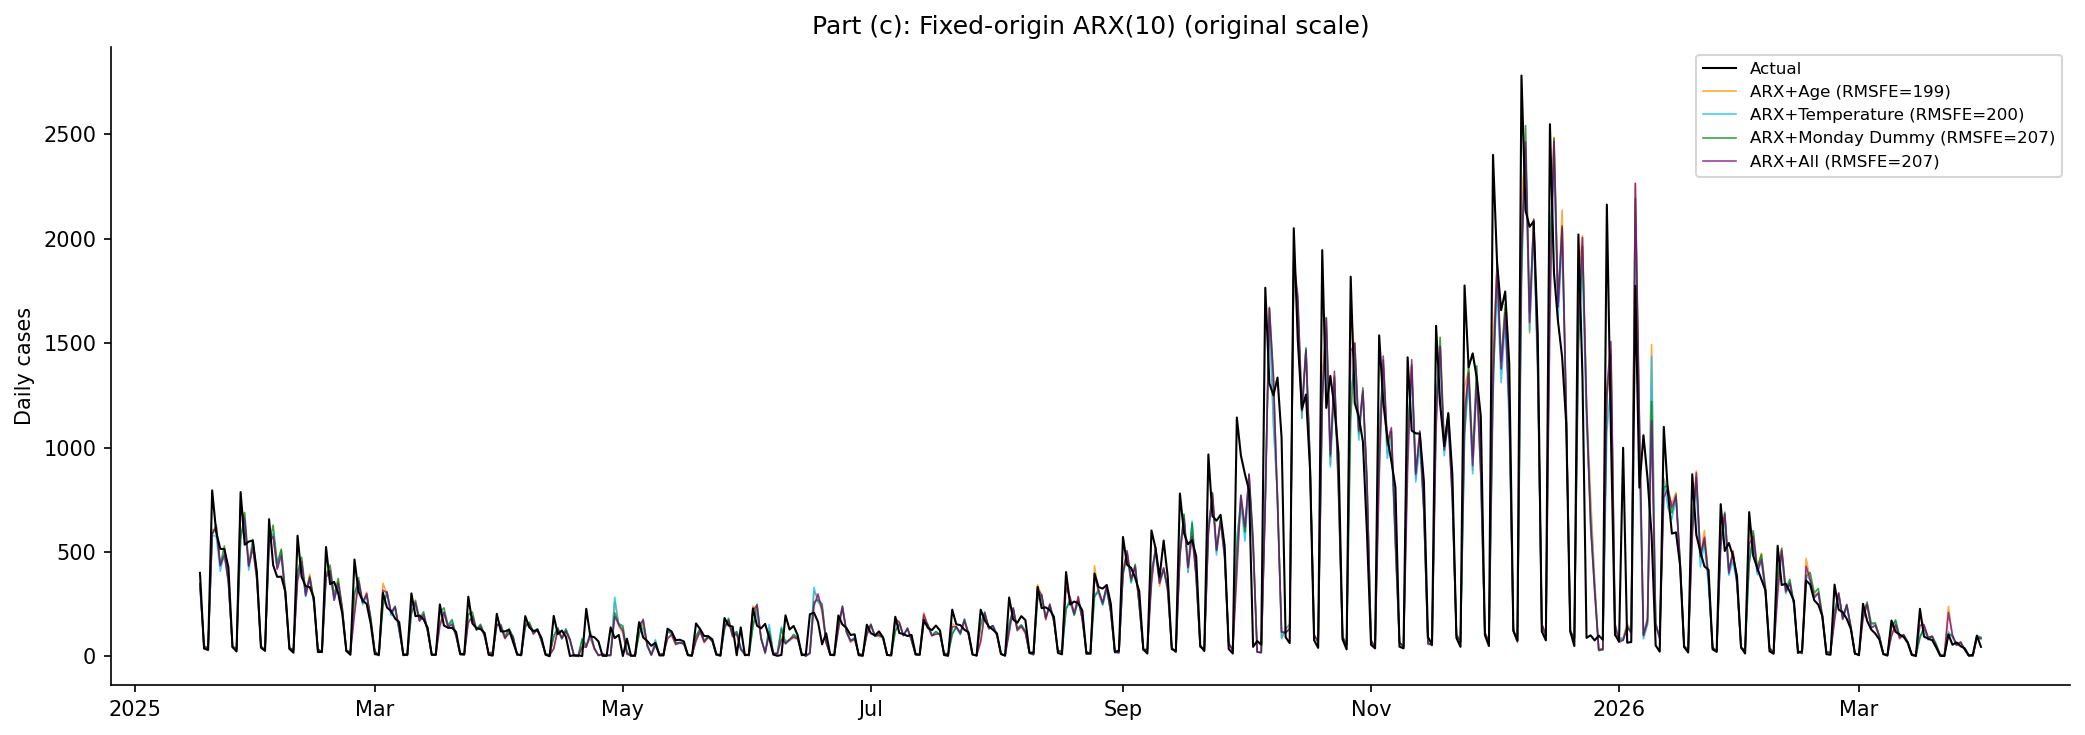

In [13]:
exog_specs = {
    "age":  age_cols,
    "temp": ["temp_lag"],
    "mon":  ["is_monday"],
    "all":  age_cols + ["temp_lag", "is_monday"],
}
nice_name = {"age": "Age", "temp": "Temperature", "mon": "Monday Dummy", "all": "All"}
results_fixed = {}

for label, cols in exog_specs.items():
    # Fit once on training data
    train_valid = train_df[["logAnzahlFall"] + cols].dropna()
    endog_train = train_valid["logAnzahlFall"]
    exog_train  = train_valid[cols]
    model_fit = AutoReg(endog_train, lags=p_fall, exog=exog_train, old_names=False).fit()

    # One-step-ahead with frozen coefficients
    y_pred_list = []
    dates_list  = []

    for t in range(n_train, n_total):
        hist_slice = df_grouped_filled.iloc[:t]
        valid_hist = hist_slice[["logAnzahlFall"] + cols].dropna()
        endog_hist = valid_hist["logAnzahlFall"]
        exog_hist  = valid_hist[cols]

        exog_oos_row = df_grouped_filled.iloc[[t]][cols]
        if exog_oos_row.isna().any(axis=None):
            y_pred_list.append(np.nan)
            dates_list.append(df_grouped_filled["Meldedatum"].iloc[t])
            continue

        fc = model_fit.apply(endog_hist, exog=exog_hist).predict(
            start=len(endog_hist), end=len(endog_hist), exog_oos=exog_oos_row)
        y_pred_list.append(fc.iloc[0])
        dates_list.append(df_grouped_filled["Meldedatum"].iloc[t])

    y_pred = pd.Series(y_pred_list, index=dates_list)

    mask = np.isfinite(test_data.values) & np.isfinite(y_pred.values)
    rms = rmsfe_level(test_data.values[mask], y_pred.values[mask])
    print(f"ARX + {nice_name[label]:12s} fixed  RMSFE(level): {rms:.2f}")

    results_fixed[label] = {
        "dates": pd.Series(dates_list),
        "actual": test_data, "pred": y_pred, "rmsfe": rms,
    }
    forecast_records[f"ARX_{label}_fixed"] = pd.Series(
        y_pred.values, index=test_df["Meldedatum"].values)

# Plot
colors_cov = {"age": "darkorange", "temp": "deepskyblue", "mon": "green", "all": "purple"}
fig, ax = plt.subplots()
ax.plot(test_df["Meldedatum"], to_level(test_df["logAnzahlFall"]),
        lw=1.0, color="black", label="Actual", zorder=5)
for label, color in colors_cov.items():
    r = results_fixed[label]
    ax.plot(r["dates"], to_level(r["pred"].values), lw=0.8, alpha=0.75, color=color,
            label=f"ARX+{nice_name[label]} (RMSFE={r['rmsfe']:.0f})")
ax.set_title(f"Part (c): Fixed-origin ARX({p_fall}) (original scale)")
ax.set_ylabel("Daily cases"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 8. Part (d): Rolling-window linear forecasts

All linear models re-estimated at each forecast origin using a **rolling window**
of width W = initial training set size.

In [14]:
# --- Rolling-window AR(p_bic) ---
series_full = df_grouped_filled["logAnzahlFall"]

y_pred_ar_roll = []
dates_ar_roll  = []

for t in range(n_train0, n_total):
    start_idx = t - WINDOW
    history = series_full.iloc[start_idx:t].dropna()
    if history.shape[0] <= p_fall:
        y_pred_ar_roll.append(np.nan)
        dates_ar_roll.append(df_grouped_filled["Meldedatum"].iloc[t])
        continue
    model_t = AutoReg(history, lags=p_fall, old_names=False).fit()
    fc = model_t.predict(start=len(history), end=len(history))
    y_pred_ar_roll.append(fc.iloc[0])
    dates_ar_roll.append(df_grouped_filled["Meldedatum"].iloc[t])

y_pred_ar_roll = pd.Series(y_pred_ar_roll, index=dates_ar_roll)
forecast_records[f"AR({p_fall})_roll"] = pd.Series(
    y_pred_ar_roll.values, index=test_df["Meldedatum"].values)

eval_ar_roll = pd.DataFrame({
    "Meldedatum": dates_ar_roll,
    "actual": series_full.iloc[n_train0:n_total].values,
    "pred": y_pred_ar_roll.values,
}).dropna()
rmsfe_ar_roll = rmsfe_level(eval_ar_roll["actual"].values, eval_ar_roll["pred"].values)
print(f"AR({p_fall}) rolling  RMSFE(level): {rmsfe_ar_roll:.2f}")

AR(10) rolling  RMSFE(level): 202.13


ARX + Age          rolling  RMSFE(level): 201.78
ARX + Temperature  rolling  RMSFE(level): 202.18
ARX + Monday Dummy rolling  RMSFE(level): 198.33
ARX + All          rolling  RMSFE(level): 197.16


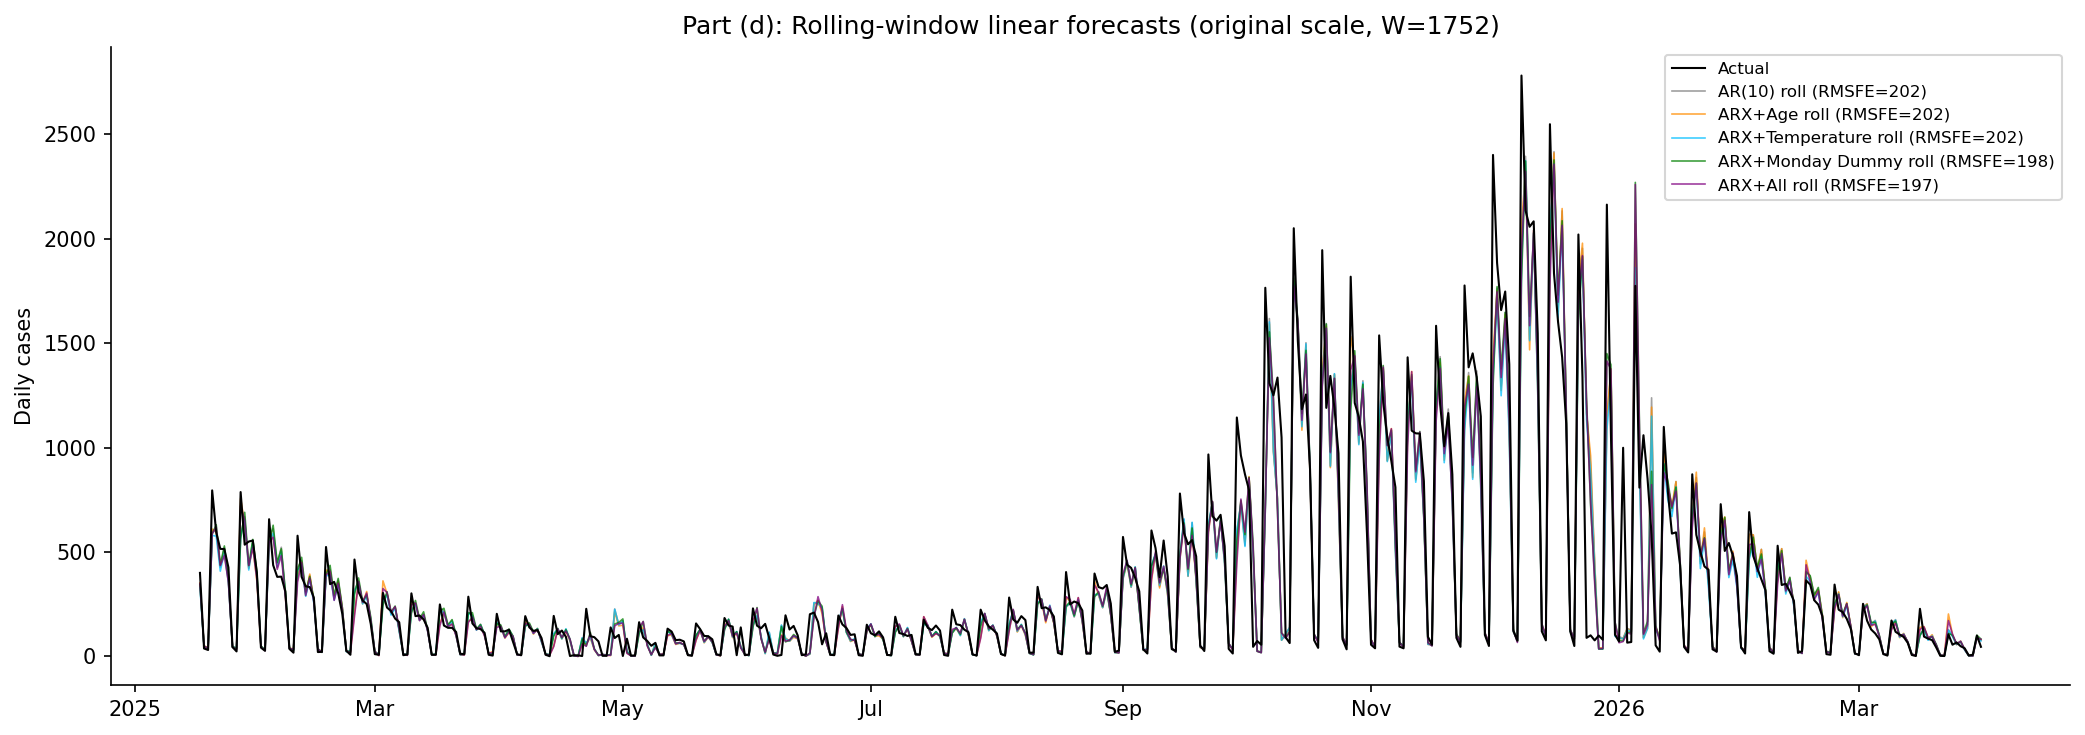

In [15]:
# --- Rolling-window ARX with each covariate + all combined ---
exog_cols_d = {
    "age":  age_cols,
    "temp": ["temp_lag"],
    "mon":  ["is_monday"],
    "all":  age_cols + ["temp_lag", "is_monday"],
}
results_arx_roll = {}

for label, cols in exog_cols_d.items():
    y_pred_list = []
    dates_list  = []

    for t in range(n_train0, n_total):
        start_idx = t - WINDOW
        hist_slice = df_grouped_filled.iloc[start_idx:t]
        valid = hist_slice[["logAnzahlFall"] + cols].dropna()

        if valid.shape[0] <= p_fall:
            y_pred_list.append(np.nan)
            dates_list.append(df_grouped_filled["Meldedatum"].iloc[t])
            continue

        endog_hist = valid["logAnzahlFall"]
        exog_hist  = valid[cols]

        exog_oos_row = df_grouped_filled.iloc[[t]][cols]
        if exog_oos_row.isna().any(axis=None):
            y_pred_list.append(np.nan)
            dates_list.append(df_grouped_filled["Meldedatum"].iloc[t])
            continue

        model_t = AutoReg(endog_hist, lags=p_fall, exog=exog_hist, old_names=False).fit()
        fc = model_t.predict(start=len(endog_hist), end=len(endog_hist),
                             exog_oos=exog_oos_row)
        y_pred_list.append(fc.iloc[0])
        dates_list.append(df_grouped_filled["Meldedatum"].iloc[t])

    eval_label = pd.DataFrame({
        "Meldedatum": dates_list,
        "actual": series_full.iloc[n_train0:n_total].values,
        "pred": y_pred_list,
    }).dropna()

    rms = rmsfe_level(eval_label["actual"].values, eval_label["pred"].values)
    print(f"ARX + {nice_name[label]:12s} rolling  RMSFE(level): {rms:.2f}")

    results_arx_roll[label] = {"eval_df": eval_label, "rmsfe": rms}
    forecast_records[f"ARX_{label}_roll"] = pd.Series(
        y_pred_list, index=test_df["Meldedatum"].values)

# Plot
fig, ax = plt.subplots()
ax.plot(test_df["Meldedatum"], to_level(test_df["logAnzahlFall"]),
        lw=1.0, color="black", label="Actual", zorder=5)
ed = eval_ar_roll
ax.plot(ed["Meldedatum"], to_level(ed["pred"]), lw=0.8, alpha=0.75, color="gray",
        label=f"AR({p_fall}) roll (RMSFE={rmsfe_ar_roll:.0f})")
for label, color in colors_cov.items():
    ed = results_arx_roll[label]["eval_df"]
    r  = results_arx_roll[label]["rmsfe"]
    ax.plot(ed["Meldedatum"], to_level(ed["pred"]), lw=0.8, alpha=0.75, color=color,
            label=f"ARX+{nice_name[label]} roll (RMSFE={r:.0f})")
ax.set_title(f"Part (d): Rolling-window linear forecasts (original scale, W={WINDOW})")
ax.set_ylabel("Daily cases"); ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

### Linear models summary

           Model Approach  RMSFE_level
         ARX+All  Rolling       197.16
ARX+Monday Dummy  Rolling       198.33
         ARX+Age    Fixed       198.97
 ARX+Temperature    Fixed       199.60
          AR(10)    Fixed       199.73
         ARX+Age  Rolling       201.78
          AR(10)  Rolling       202.13
 ARX+Temperature  Rolling       202.18
         ARX+All    Fixed       206.61
ARX+Monday Dummy    Fixed       207.38
           AR(7)    Fixed       223.73


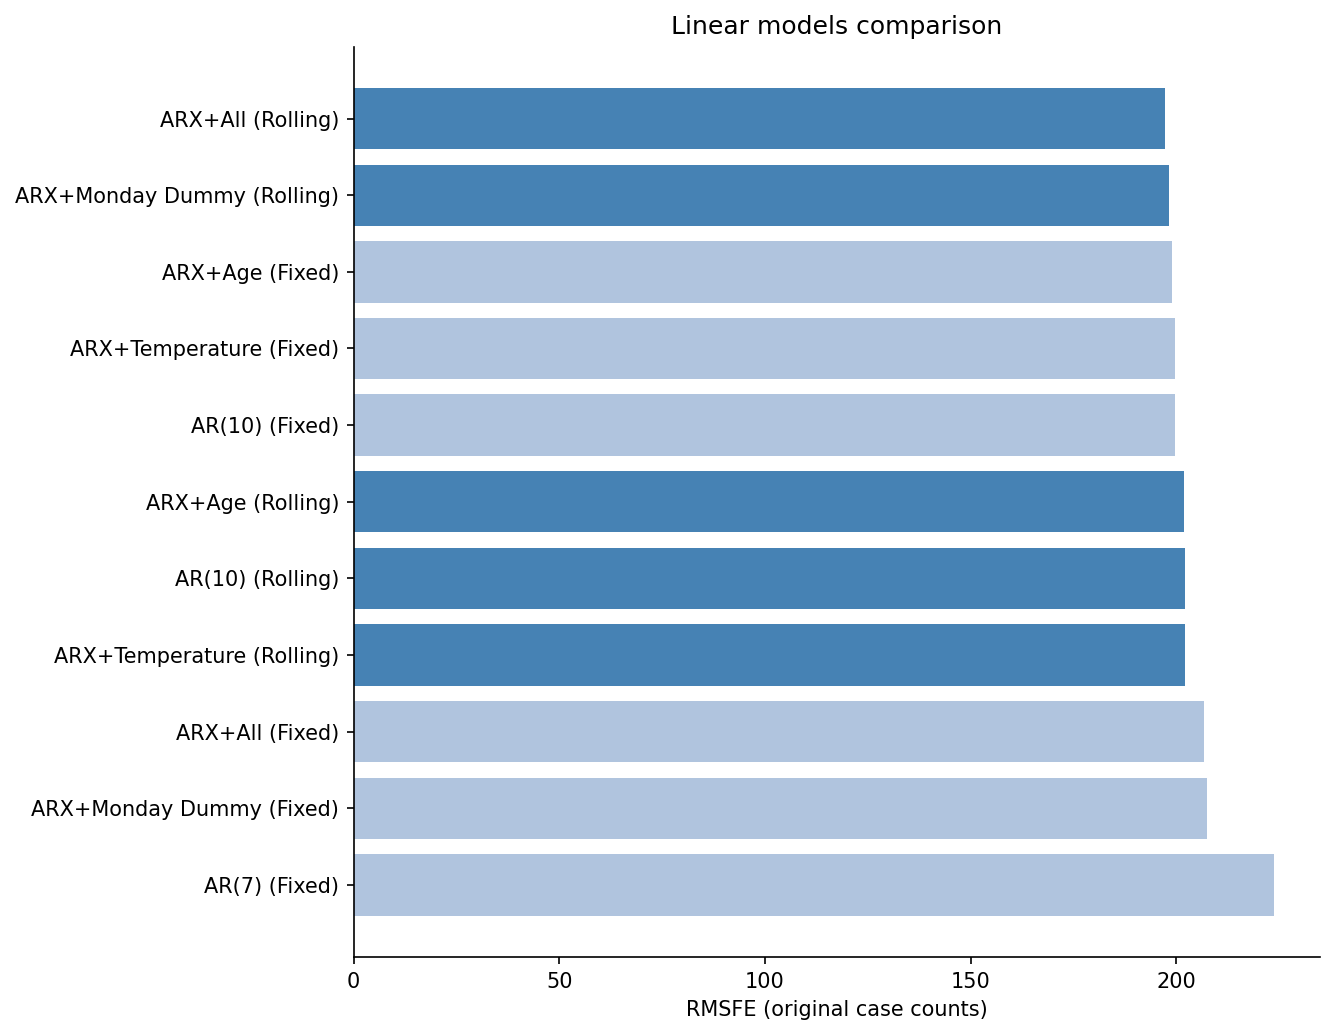

In [16]:
summary_rows = [
    {"Model": "AR(7)",         "Approach": "Fixed",   "RMSFE_level": rmsfe_ar7},
    {"Model": f"AR({p_fall})", "Approach": "Fixed",   "RMSFE_level": rmsfe_bic},
    {"Model": f"AR({p_fall})", "Approach": "Rolling", "RMSFE_level": rmsfe_ar_roll},
]
for label in ["age", "temp", "mon", "all"]:
    summary_rows.append({"Model": f"ARX+{nice_name[label]}", "Approach": "Fixed",
                          "RMSFE_level": results_fixed[label]["rmsfe"]})
    summary_rows.append({"Model": f"ARX+{nice_name[label]}", "Approach": "Rolling",
                          "RMSFE_level": results_arx_roll[label]["rmsfe"]})

summary_df = pd.DataFrame(summary_rows).sort_values("RMSFE_level").reset_index(drop=True)
summary_df["RMSFE_level"] = summary_df["RMSFE_level"].round(2)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
labels_bar = summary_df["Model"] + " (" + summary_df["Approach"] + ")"
colors_bar = summary_df["Approach"].map({"Fixed": "lightsteelblue", "Rolling": "steelblue"})
ax.barh(labels_bar, summary_df["RMSFE_level"], color=colors_bar)
ax.set_xlabel("RMSFE (original case counts)"); ax.set_title("Linear models comparison")
ax.invert_yaxis(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 9. Parts (e) & (f): Decision Tree & Random Forest

Rolling-window re-estimation with window size W = initial training set.

**Part (e):** lags 1--10 only.
**Part (f):** lags 1--10 + covariates (age shares lagged 1--10, temperature
lagged 1--10, Monday dummy unlagged).

Weekly hyperparameter tuning via `RandomizedSearchCV` with `TimeSeriesSplit`.

In [17]:
# --- Build lag feature table ---
def make_lag_features(series, p):
    df_feat = pd.DataFrame({"y": series})
    for lag in range(1, p + 1):
        df_feat[f"lag_{lag}"] = series.shift(lag)
    return df_feat.dropna()

p_ml = p_fall
feat_full = make_lag_features(
    df_grouped_filled.set_index("Meldedatum")["logAnzahlFall"], p_ml
).reset_index(names="Meldedatum")

lag_cols = [f"lag_{l}" for l in range(1, p_ml + 1)]
feat_dates = feat_full["Meldedatum"]

# --- Build covariate lags 1..10 for age shares and temperature ---
df_cov_base = df_grouped_filled.set_index("Meldedatum")[
    age_cols + ["temperature", "is_monday"]
].copy()

cov_lag_cols = []
for col in age_cols + ["temperature"]:
    for lag in range(1, p_ml + 1):
        col_name = f"{col}_lag{lag}"
        df_cov_base[col_name] = df_cov_base[col].shift(lag)
        cov_lag_cols.append(col_name)

# Monday dummy: deterministic calendar variable known in advance -> unlagged
cov_lag_cols += ["is_monday"]

# Drop original unlagged columns
df_cov_base = df_cov_base.drop(columns=age_cols + ["temperature"])

feat_cov_full = feat_full.merge(
    df_cov_base.reset_index(names="Meldedatum"), on="Meldedatum", how="left",
)
all_feat_cols = lag_cols + cov_lag_cols
feat_cov_dates = feat_cov_full["Meldedatum"]

print(f"Lags-only features ({len(lag_cols)}): {lag_cols}")
print(f"Covariate features ({len(cov_lag_cols)}): {len(cov_lag_cols) - 1} lagged + is_monday")
print(f"Total features for ML+cov: {len(all_feat_cols)}")
# -> 71 features: 10 lags + 50 age + 10 temp + 1 monday

Lags-only features (10): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10']
Covariate features (61): 60 lagged + is_monday
Total features for ML+cov: 71


=== Part (e): ML with lags only (rolling window) ===
  [2025-01-17] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-01-31] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-02-14] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-02-28] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-03-14] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-03-28] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-04-11] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-04-25] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-05-09] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-05-23] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-06-06] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-06-20] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-07-04] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-07-18] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-08-01] Tuned -> {'max_depth': 7,

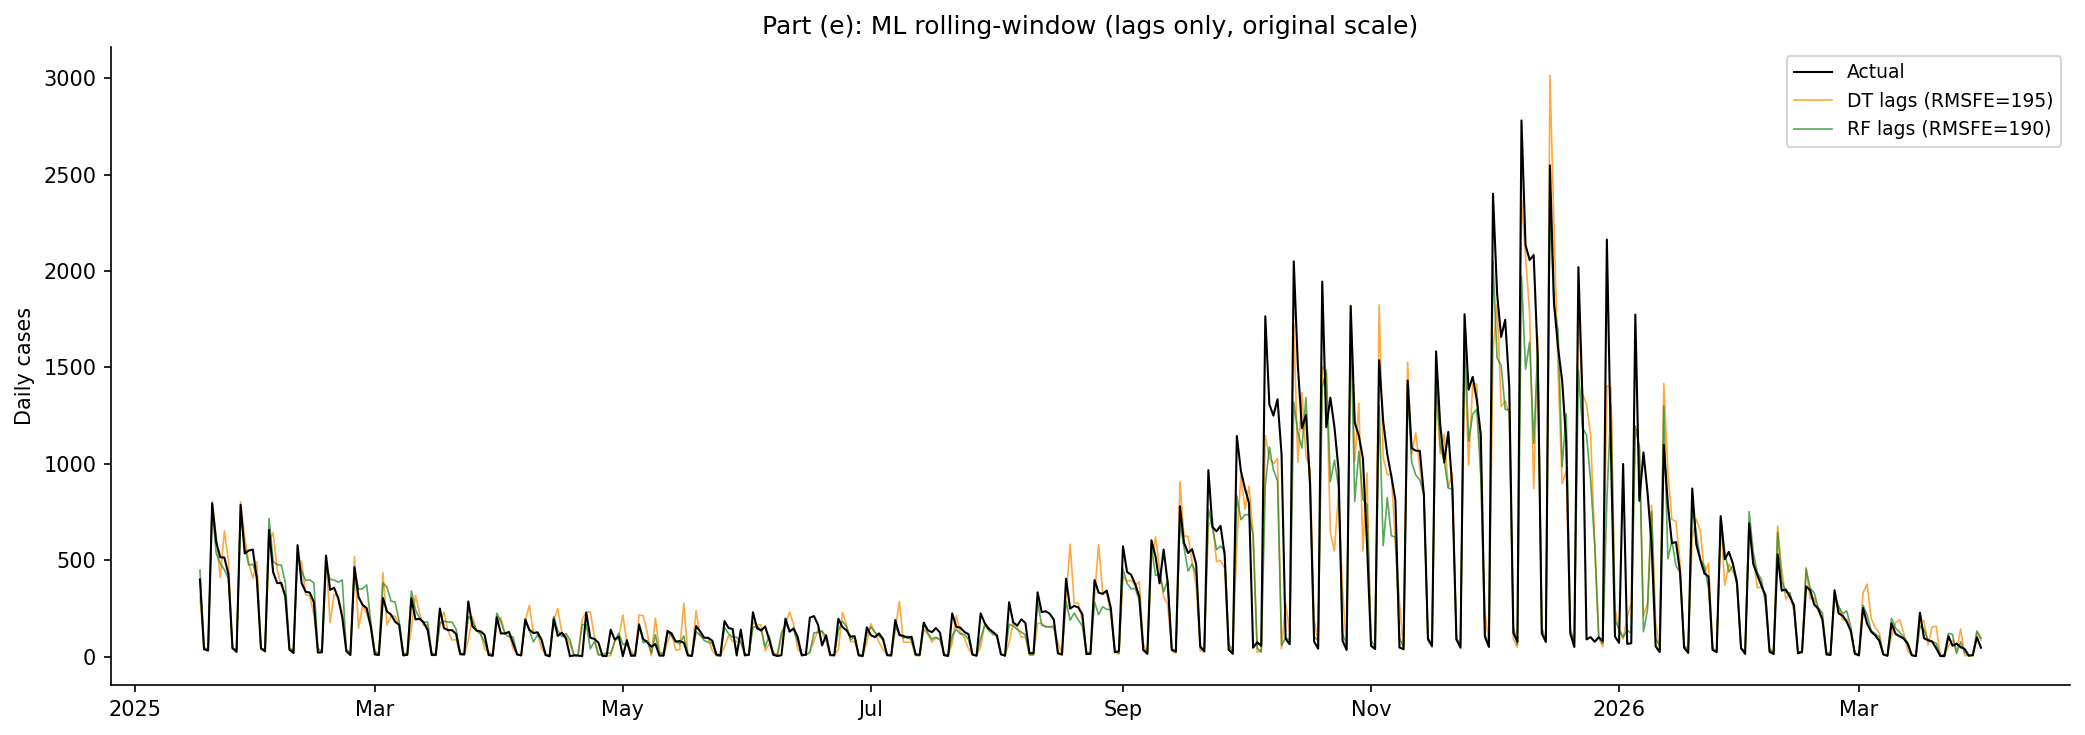

In [18]:
# --- Hyperparameter distributions ---
param_dist_dt = {
    "max_depth":        randint(2, 20),
    "min_samples_leaf": randint(5, 100),
}
param_dist_rf = {
    "n_estimators": randint(50, 200),
    "max_depth":    randint(2, 15),
    "max_features": uniform(0.1, 0.89),
}

# --- Rolling-window ML with biweekly hyperparameter tuning ---
def rolling_window_ml(model_class, param_dist, label, feat_df, feature_cols,
                      window, tune_every=14):
    y_pred_list  = []
    dates_list   = []
    best_params  = None
    last_tune_i  = -tune_every
    _dates       = feat_df["Meldedatum"]

    target_dates = df_grouped_filled["Meldedatum"].iloc[n_train0:n_total]

    for i, target_date in enumerate(target_dates):
        mask_before = _dates < target_date
        available = feat_df.loc[mask_before]

        if len(available) < window:
            train_chunk = available
        else:
            train_chunk = available.iloc[-window:]

        test_mask = _dates == target_date

        if len(train_chunk) == 0 or test_mask.sum() == 0:
            y_pred_list.append(np.nan); dates_list.append(target_date); continue

        train_clean = train_chunk[["y"] + feature_cols].dropna()
        if train_clean.empty:
            y_pred_list.append(np.nan); dates_list.append(target_date); continue

        X_train = train_clean[feature_cols]
        y_train = train_clean["y"]
        X_test  = feat_df.loc[test_mask, feature_cols]

        if X_test.isna().any(axis=None):
            y_pred_list.append(np.nan); dates_list.append(target_date); continue

        # --- Biweekly hyperparameter tuning ---
        if (i - last_tune_i) >= tune_every:
            tscv = TimeSeriesSplit(n_splits=3)
            search = RandomizedSearchCV(
                model_class(), param_distributions=param_dist,
                n_iter=20, cv=tscv, scoring="neg_mean_squared_error",
                random_state=42, n_jobs=-1,
            )
            search.fit(X_train, y_train)
            best_params = search.best_params_
            last_tune_i = i
            print(f"  [{target_date.date()}] Tuned -> {best_params}")

        # --- Daily refit with best params ---
        model_t = model_class(**best_params, random_state=42)
        model_t.fit(X_train, y_train)
        y_pred_list.append(model_t.predict(X_test)[0])
        dates_list.append(target_date)

    eval_df = pd.DataFrame({
        "Meldedatum": dates_list,
        "actual": df_grouped_filled.set_index("Meldedatum")
                  .loc[dates_list, "logAnzahlFall"].values,
        "pred": y_pred_list,
    }).dropna()

    rms = rmsfe_level(eval_df["actual"].values, eval_df["pred"].values)
    print(f"{label:40s}  RMSFE(level): {rms:.2f}")
    return eval_df, rms, y_pred_list


# === Part (e): lags only ===
print("=== Part (e): ML with lags only (rolling window) ===")
t0 = time.time()

eval_dt_lags, rmsfe_dt_lags, pred_dt_lags = rolling_window_ml(
    DecisionTreeRegressor, param_dist_dt,
    "Decision Tree (lags)", feat_full, lag_cols, WINDOW)
forecast_records["DT_lags"] = pd.Series(pred_dt_lags, index=test_df["Meldedatum"].values)

eval_rf_lags, rmsfe_rf_lags, pred_rf_lags = rolling_window_ml(
    RandomForestRegressor, param_dist_rf,
    "Random Forest (lags)", feat_full, lag_cols, WINDOW)
forecast_records["RF_lags"] = pd.Series(pred_rf_lags, index=test_df["Meldedatum"].values)

print(f"\nPart (e) done in {time.time()-t0:.0f}s")

fig, ax = plt.subplots()
ax.plot(test_df["Meldedatum"], to_level(test_df["logAnzahlFall"]),
        lw=1.0, color="black", label="Actual", zorder=5)
ax.plot(eval_dt_lags["Meldedatum"], to_level(eval_dt_lags["pred"]),
        lw=0.8, alpha=0.75, color="darkorange", label=f"DT lags (RMSFE={rmsfe_dt_lags:.0f})")
ax.plot(eval_rf_lags["Meldedatum"], to_level(eval_rf_lags["pred"]),
        lw=0.8, alpha=0.75, color="forestgreen", label=f"RF lags (RMSFE={rmsfe_rf_lags:.0f})")
ax.set_title("Part (e): ML rolling-window (lags only, original scale)")
ax.set_ylabel("Daily cases"); ax.legend()
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

=== Part (f): ML with lags + covariates (rolling window) ===


  [2025-01-17] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-01-31] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-02-14] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-02-28] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-03-14] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-03-28] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-04-11] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-04-25] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-05-09] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-05-23] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-06-06] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-06-20] Tuned -> {'max_depth': 19, 'min_samples_leaf': 8}
  [2025-07-04] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-07-18] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-08-01] Tuned -> {'max_depth': 7, 'min_samples_leaf': 6}
  [2025-08-15] Tuned -> {'max_dept

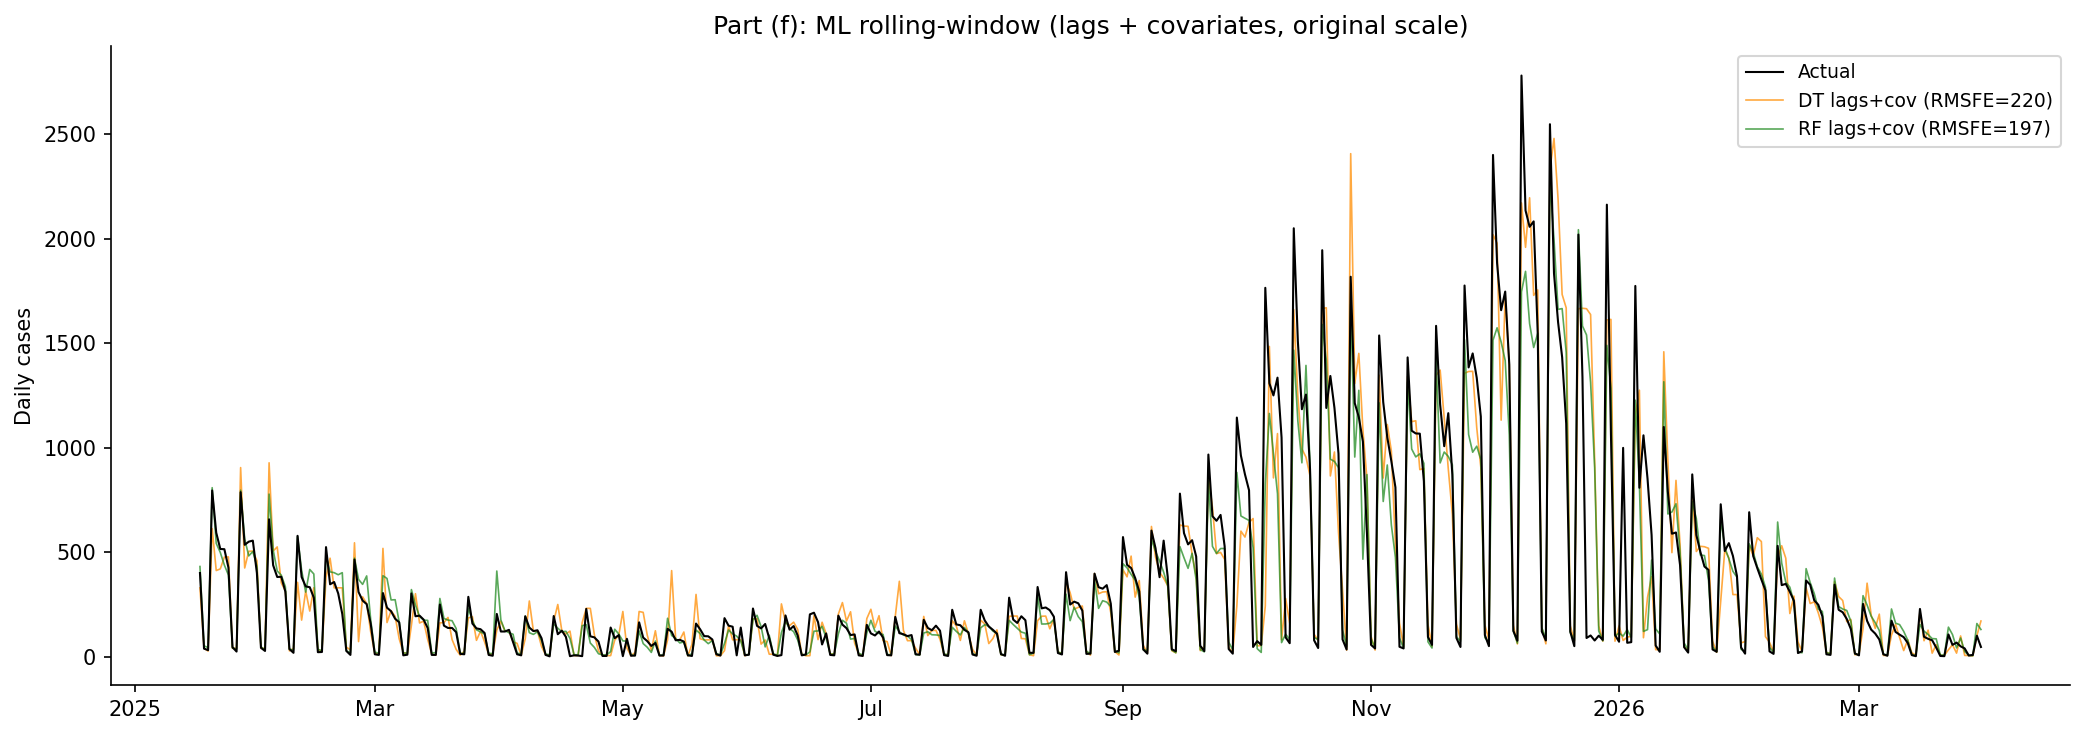

In [19]:
# === Part (f): lags + covariates ===
print("=== Part (f): ML with lags + covariates (rolling window) ===")
t0 = time.time()

eval_dt_cov, rmsfe_dt_cov, pred_dt_cov = rolling_window_ml(
    DecisionTreeRegressor, param_dist_dt,
    "Decision Tree (lags+cov)", feat_cov_full, all_feat_cols, WINDOW)
forecast_records["DT_cov"] = pd.Series(pred_dt_cov, index=test_df["Meldedatum"].values)

eval_rf_cov, rmsfe_rf_cov, pred_rf_cov = rolling_window_ml(
    RandomForestRegressor, param_dist_rf,
    "Random Forest (lags+cov)", feat_cov_full, all_feat_cols, WINDOW)
forecast_records["RF_cov"] = pd.Series(pred_rf_cov, index=test_df["Meldedatum"].values)

print(f"\nPart (f) done in {time.time()-t0:.0f}s")

fig, ax = plt.subplots()
ax.plot(test_df["Meldedatum"], to_level(test_df["logAnzahlFall"]),
        lw=1.0, color="black", label="Actual", zorder=5)
ax.plot(eval_dt_cov["Meldedatum"], to_level(eval_dt_cov["pred"]),
        lw=0.8, alpha=0.75, color="darkorange", label=f"DT lags+cov (RMSFE={rmsfe_dt_cov:.0f})")
ax.plot(eval_rf_cov["Meldedatum"], to_level(eval_rf_cov["pred"]),
        lw=0.8, alpha=0.75, color="forestgreen", label=f"RF lags+cov (RMSFE={rmsfe_rf_cov:.0f})")
ax.set_title("Part (f): ML rolling-window (lags + covariates, original scale)")
ax.set_ylabel("Daily cases"); ax.legend()
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 10. Feature Importance: Decision Tree vs Random Forest

Impurity-based importance from both models trained on the full training
set (with covariates).

DT best params: {'max_depth': 19, 'min_samples_leaf': 8}
RF best params: {'max_depth': 12, 'max_features': np.float64(0.7939249902427646), 'n_estimators': 70}


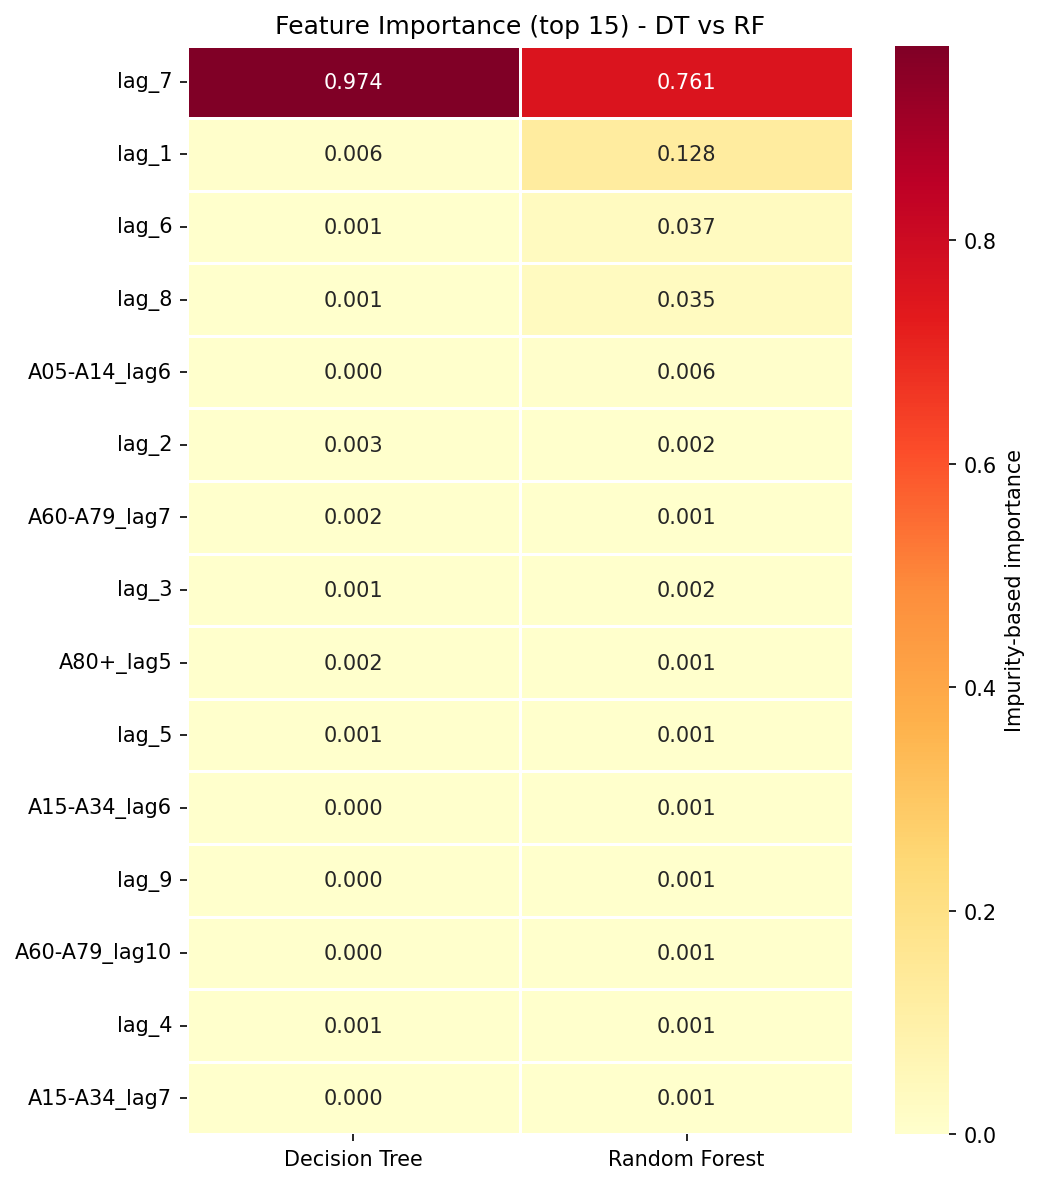

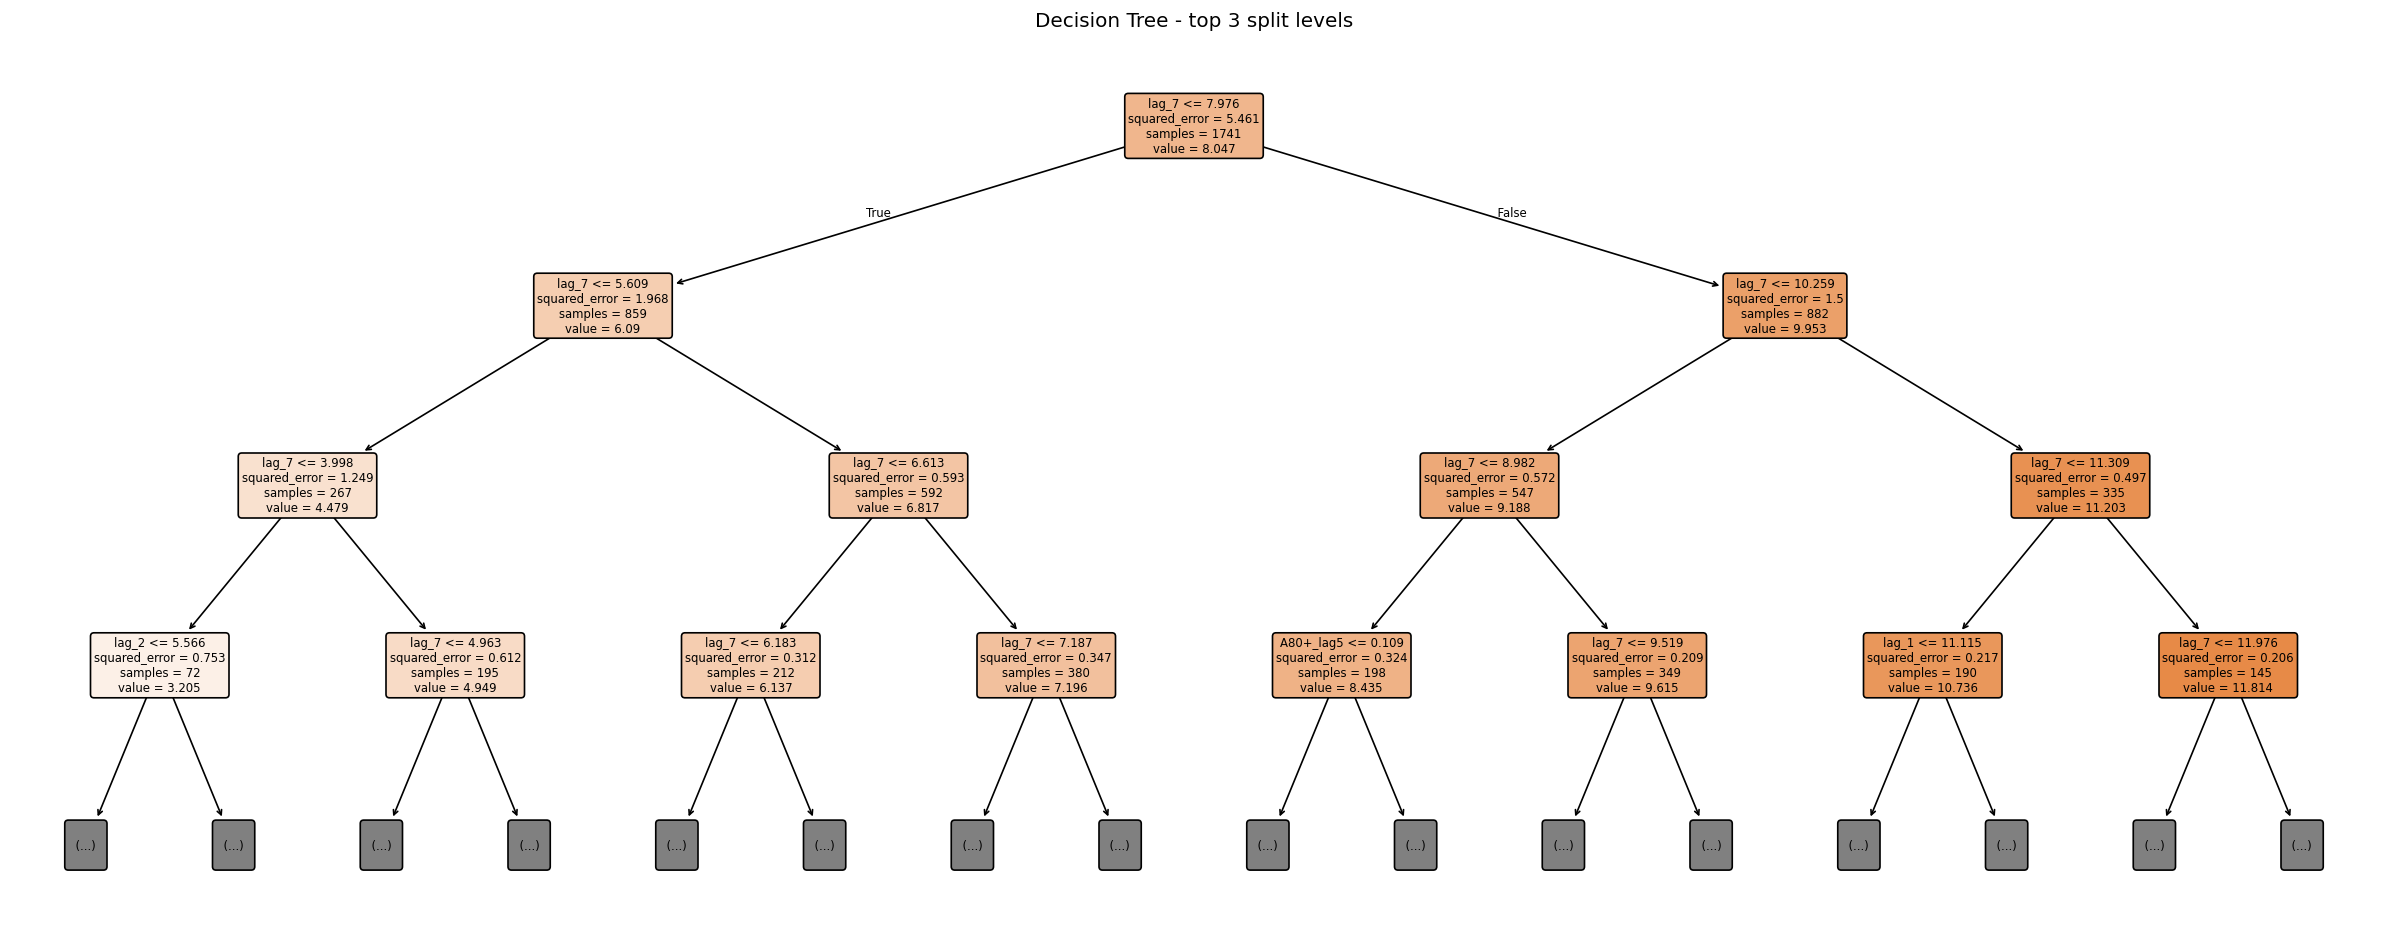


Top 5 per method:

Decision Tree:
  lag_7                 0.9739
  lag_1                 0.0056
  lag_2                 0.0035
  A60-A79_lag7          0.0016
  A80+_lag5             0.0015

Random Forest:
  lag_7                 0.7608
  lag_1                 0.1278
  lag_6                 0.0367
  lag_8                 0.0349
  A05-A14_lag6          0.0056


In [20]:
# Use best params from the last RF tuning round
# (available after cell 28 has run)

train_mask_imp = feat_cov_dates < test_df["Meldedatum"].iloc[0]
train_rows_imp = feat_cov_full.loc[train_mask_imp, ["y"] + all_feat_cols].dropna()

X_imp = train_rows_imp[all_feat_cols]
y_imp = train_rows_imp["y"]

# --- Tune on training data (same procedure as rolling window) ---
tscv = TimeSeriesSplit(n_splits=3)

search_dt = RandomizedSearchCV(
    DecisionTreeRegressor(), param_distributions=param_dist_dt,
    n_iter=20, cv=tscv, scoring="neg_mean_squared_error",
    random_state=42, n_jobs=-1,
)
search_dt.fit(X_imp, y_imp)
dt_imp = search_dt.best_estimator_
print(f"DT best params: {search_dt.best_params_}")

search_rf = RandomizedSearchCV(
    RandomForestRegressor(), param_distributions=param_dist_rf,
    n_iter=20, cv=tscv, scoring="neg_mean_squared_error",
    random_state=42, n_jobs=-1,
)
search_rf.fit(X_imp, y_imp)
rf_imp = search_rf.best_estimator_
print(f"RF best params: {search_rf.best_params_}")

# --- Importance table ---
imp = pd.DataFrame({
    "Feature": all_feat_cols,
    "Decision Tree": dt_imp.feature_importances_,
    "Random Forest": rf_imp.feature_importances_,
})
imp["max_imp"] = imp[["Decision Tree", "Random Forest"]].max(axis=1)
imp_top = imp.nlargest(15, "max_imp").drop(columns="max_imp").set_index("Feature")

# Heatmap
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(imp_top, annot=True, fmt=".3f", cmap="YlOrRd",
            linewidths=0.5, vmin=0, ax=ax,
            cbar_kws={"label": "Impurity-based importance"})
ax.set_title("Feature Importance (top 15) - DT vs RF")
ax.set_ylabel("")
plt.tight_layout(); plt.savefig("fig_importance_heatmap.png", bbox_inches="tight"); plt.show()

# Tree structure
fig, ax = plt.subplots(figsize=(20, 8), dpi=120)
plot_tree(dt_imp, feature_names=all_feat_cols, filled=True,
          rounded=True, fontsize=7, ax=ax, max_depth=3)
ax.set_title("Decision Tree - top 3 split levels")
plt.tight_layout(); plt.savefig("fig_tree_structure.png", bbox_inches="tight"); plt.show()

# Summary
print("\nTop 5 per method:")
print("\nDecision Tree:")
for _, r in imp.nlargest(5, "Decision Tree").iterrows():
    print(f"  {r['Feature']:20s}  {r['Decision Tree']:.4f}")
print("\nRandom Forest:")
for _, r in imp.nlargest(5, "Random Forest").iterrows():
    print(f"  {r['Feature']:20s}  {r['Random Forest']:.4f}")

## 11. Part (g): RMSFE summary - all models

Primary metric: **RMSFE on original case counts**.

=== RMSFE on original case counts ===
         Model  RMSFE_level
       RF_lags       189.59
       DT_lags       194.51
        RF_cov       196.97
  ARX_all_roll       197.16
  ARX_mon_roll       198.33
 ARX_age_fixed       198.97
ARX_temp_fixed       199.60
  AR(10)_fixed       199.73
  ARX_age_roll       201.78
   AR(10)_roll       202.13
 ARX_temp_roll       202.18
 ARX_all_fixed       206.61
 ARX_mon_fixed       207.38
        DT_cov       220.07
   AR(7)_fixed       223.73


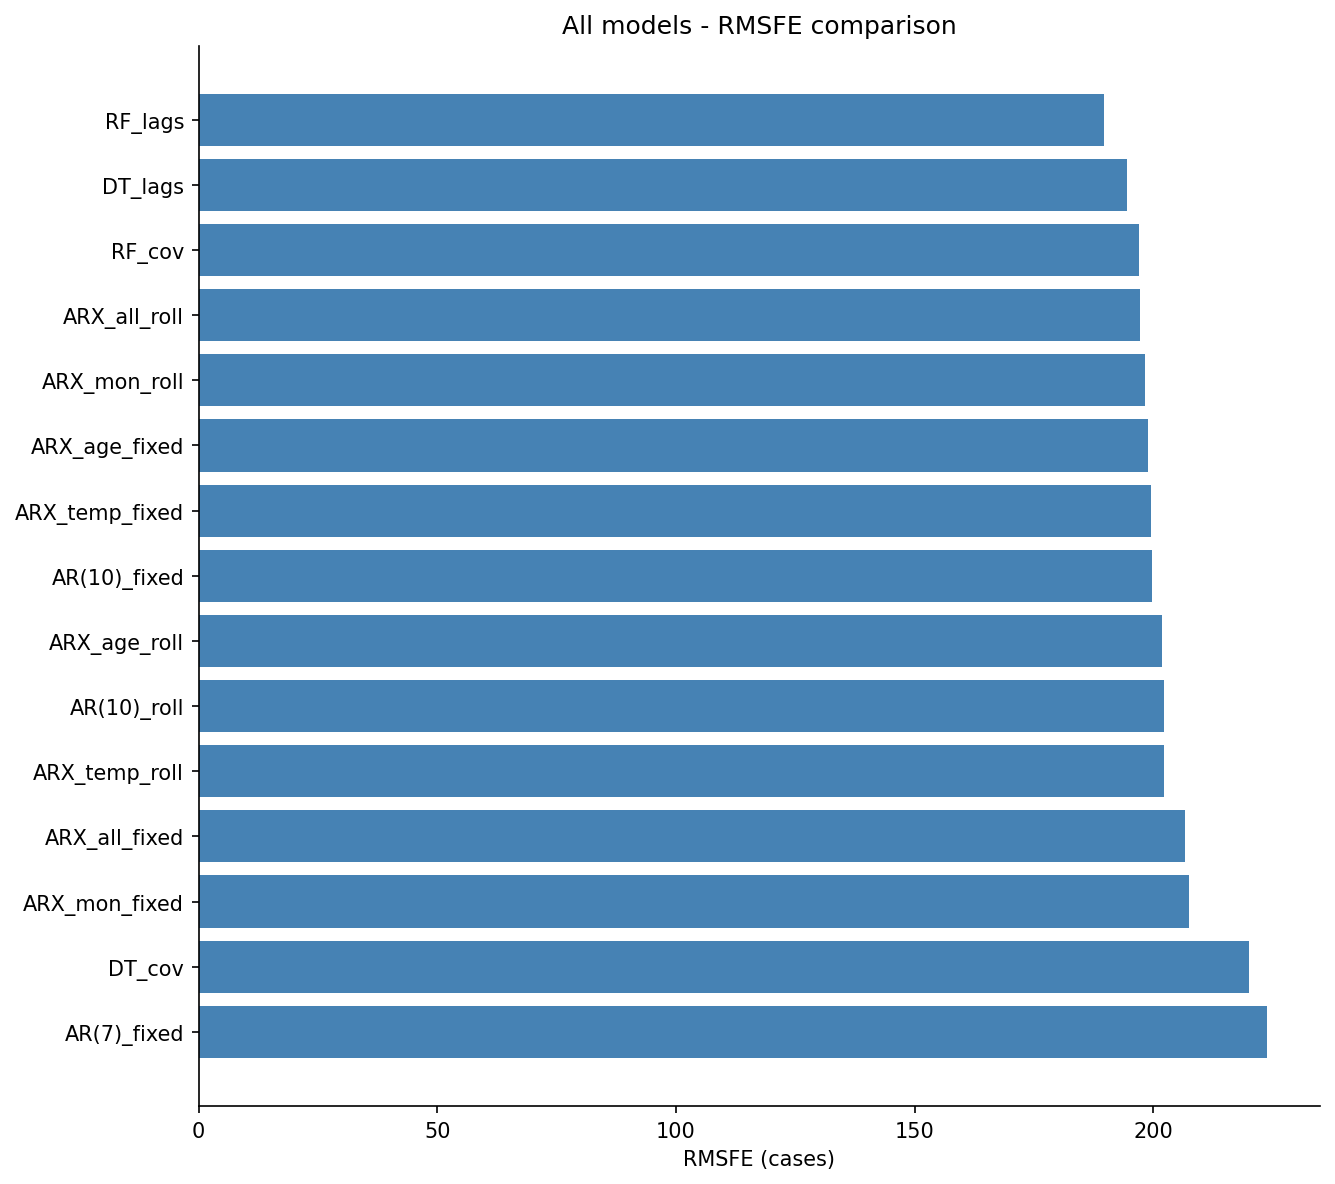

Saved CSV files.


In [21]:
forecast_df = pd.DataFrame(forecast_records)
forecast_df = forecast_df.join(
    test_df.set_index("Meldedatum")["logAnzahlFall"].rename("actual"), how="left"
)

# Back-transform
cols_tf = [c for c in forecast_df.columns if c != "actual"]
forecast_df_levels = forecast_df.copy()
for c in cols_tf + ["actual"]:
    forecast_df_levels[c] = to_level(forecast_df[c])

# RMSFE table
model_cols = [c for c in forecast_df_levels.columns if c != "actual"]
actual_lvl = forecast_df_levels["actual"]

rmsfe_rows = []
for c in model_cols:
    mask = forecast_df_levels[c].notna() & actual_lvl.notna()
    if mask.sum() < 10: continue
    rms = float(np.sqrt(np.mean((actual_lvl[mask] - forecast_df_levels[c][mask])**2)))
    rmsfe_rows.append({"Model": c, "RMSFE_level": round(rms, 2)})

rmsfe_tbl = pd.DataFrame(rmsfe_rows).sort_values("RMSFE_level").reset_index(drop=True)
print("=== RMSFE on original case counts ===")
print(rmsfe_tbl.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(rmsfe_tbl["Model"], rmsfe_tbl["RMSFE_level"], color="steelblue")
ax.set_xlabel("RMSFE (cases)"); ax.set_title("All models - RMSFE comparison")
ax.invert_yaxis(); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

rmsfe_tbl.to_csv("project3_rmsfe_table.csv", index=False)
forecast_df.to_csv("project3_forecasts_log.csv")
print("Saved CSV files.")

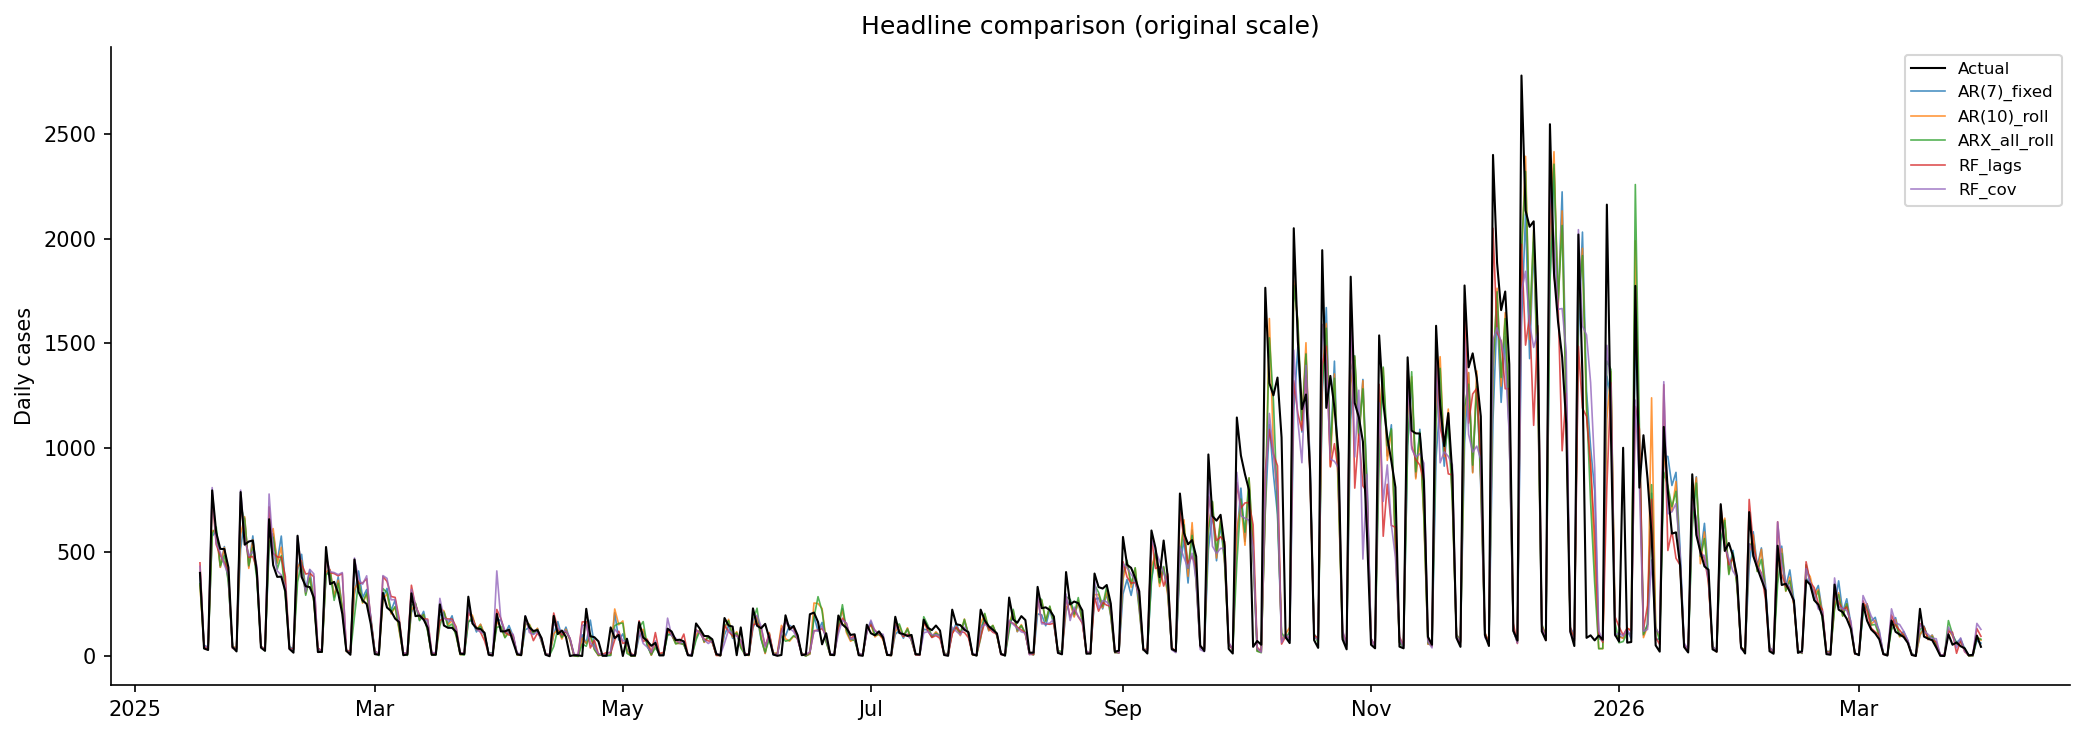

In [32]:
# --- Headline comparison ---
headline = ["AR(7)_fixed", f"AR({p_fall})_roll", "ARX_all_roll", "RF_lags", "RF_cov"]
headline = [h for h in headline if h in forecast_df_levels.columns]

fig, ax = plt.subplots()
ax.plot(forecast_df_levels.index, forecast_df_levels["actual"],
        lw=1.0, color="black", label="Actual", zorder=5)
for c in headline:
    ax.plot(forecast_df_levels.index, forecast_df_levels[c], lw=0.8, alpha=0.8, label=c)
ax.set_title("Headline comparison (original scale)"); ax.set_ylabel("Daily cases")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Diebold-Mariano tests

Two-sided DM test with Harvey/Leybourne/Newbold (1997) finite-sample correction.
Loss: **squared errors on original scale**. Bonferroni correction for multiple testing.

In [23]:
# ============================================================
# 12a. DM test function + pairwise computation
# ============================================================

def diebold_mariano(actual, pred1, pred2, h=1):
    e1 = actual - pred1
    e2 = actual - pred2
    d  = e1**2 - e2**2
    T  = len(d)
    d_bar = np.mean(d)
    max_lag = max(h - 1, 0)
    gamma_0 = np.var(d, ddof=0)
    nw_var  = gamma_0
    for lag in range(1, max_lag + 1):
        gamma_l = np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar))
        nw_var += 2 * gamma_l
    nw_var = max(nw_var, 1e-12)
    hln_var = (T + 1 - 2*h + h*(h-1)/T) / T * nw_var
    dm_stat = d_bar / np.sqrt(hln_var / T)
    p_value = 2 * t_dist.sf(np.abs(dm_stat), df=T - 1)
    return dm_stat, p_value

# Pairwise DM (on original scale)
model_cols_dm = [c for c in model_cols if forecast_df_levels[c].notna().sum() >= 30]
actual_dm = forecast_df_levels["actual"].values
n_m = len(model_cols_dm)

dm_stats = pd.DataFrame(np.nan, index=model_cols_dm, columns=model_cols_dm)
dm_pvals = pd.DataFrame(np.nan, index=model_cols_dm, columns=model_cols_dm)

for m1, m2 in itertools.combinations(model_cols_dm, 2):
    mask = (forecast_df_levels[m1].notna() &
            forecast_df_levels[m2].notna() &
            forecast_df_levels["actual"].notna())
    act = actual_dm[mask]
    p1  = forecast_df_levels.loc[mask, m1].values
    p2  = forecast_df_levels.loc[mask, m2].values
    stat, pval = diebold_mariano(act, p1, p2, h=1)
    dm_stats.loc[m1, m2] =  stat
    dm_stats.loc[m2, m1] = -stat
    dm_pvals.loc[m1, m2] =  pval
    dm_pvals.loc[m2, m1] =  pval

np.fill_diagonal(dm_stats.values, 0.0)
np.fill_diagonal(dm_pvals.values, 1.0)

# Bonferroni correction
n_tests = len(list(itertools.combinations(model_cols_dm, 2)))
print(f"Number of pairwise tests: {n_tests}")
print(f"Bonferroni threshold (alpha=0.05): {0.05/n_tests:.5f}")

dm_pvals_bonf = dm_pvals.copy()
for m1, m2 in itertools.combinations(model_cols_dm, 2):
    p_adj = min(dm_pvals.loc[m1, m2] * n_tests, 1.0)
    dm_pvals_bonf.loc[m1, m2] = p_adj
    dm_pvals_bonf.loc[m2, m1] = p_adj
np.fill_diagonal(dm_pvals_bonf.values, 1.0)

Number of pairwise tests: 105
Bonferroni threshold (alpha=0.05): 0.00048


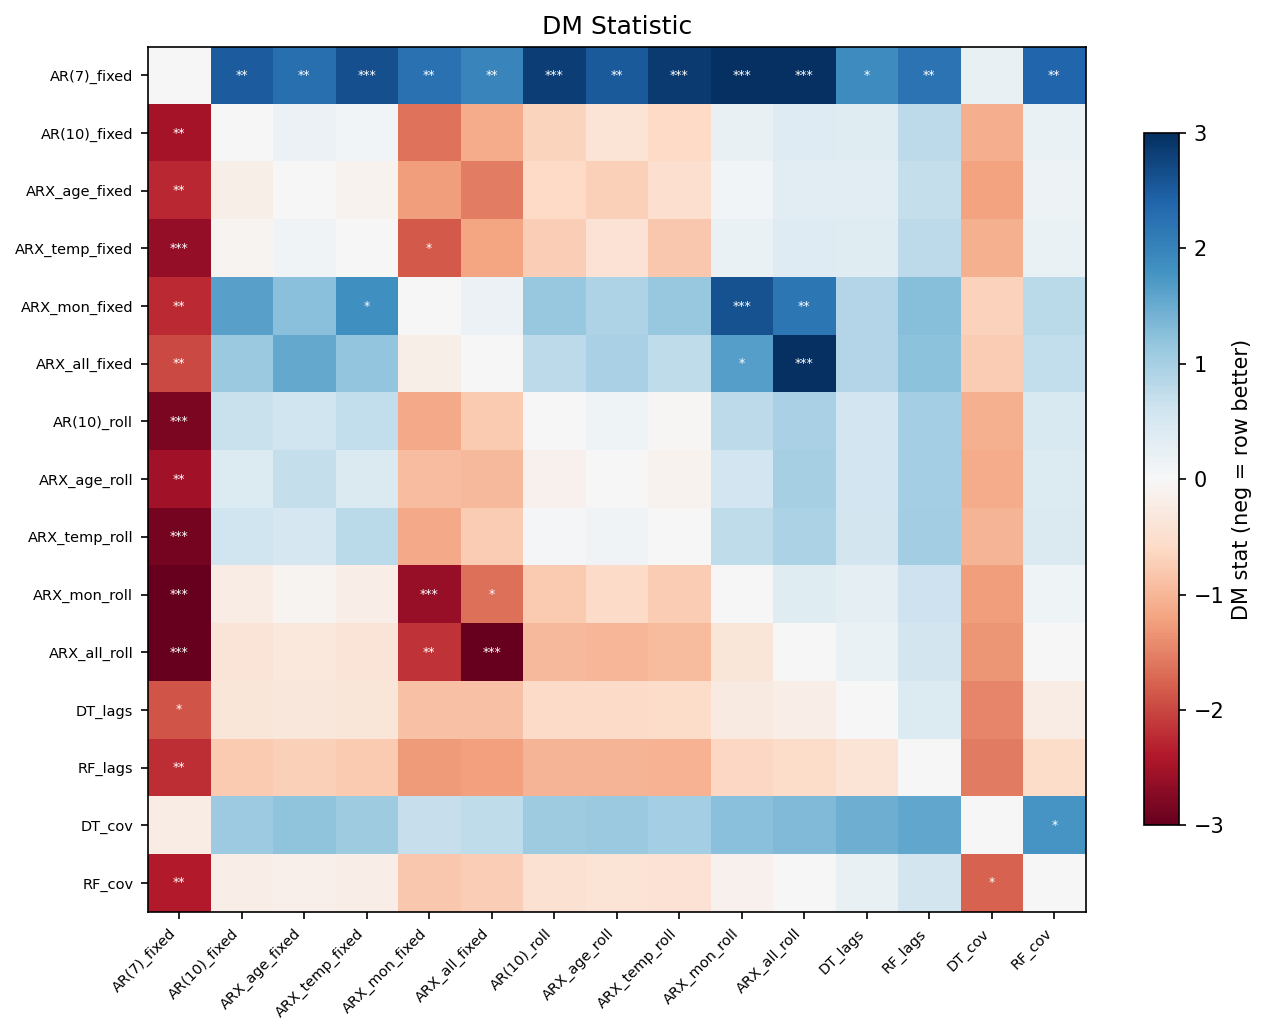

In [27]:
# ============================================================
# 12b-i. Heatmap: DM statistics
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7), dpi=150)
im = ax.imshow(dm_stats.values.astype(float), cmap="RdBu", vmin=-3, vmax=3, aspect="auto")
plt.colorbar(im, ax=ax, label="DM stat (neg = row better)", shrink=0.8)
ax.set_xticks(range(n_m)); ax.set_xticklabels(model_cols_dm, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_m)); ax.set_yticklabels(model_cols_dm, fontsize=7)
ax.set_title("DM Statistic")
for i in range(n_m):
    for j in range(n_m):
        if i == j: continue
        p = dm_pvals.iloc[i, j]
        stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        if stars:
            ax.text(j, i, stars, ha="center", va="center", fontsize=6,
                    color="white" if abs(dm_stats.iloc[i,j]) > 1.5 else "black")
plt.tight_layout(); plt.savefig("fig_dm_stats.png", bbox_inches="tight"); plt.show()


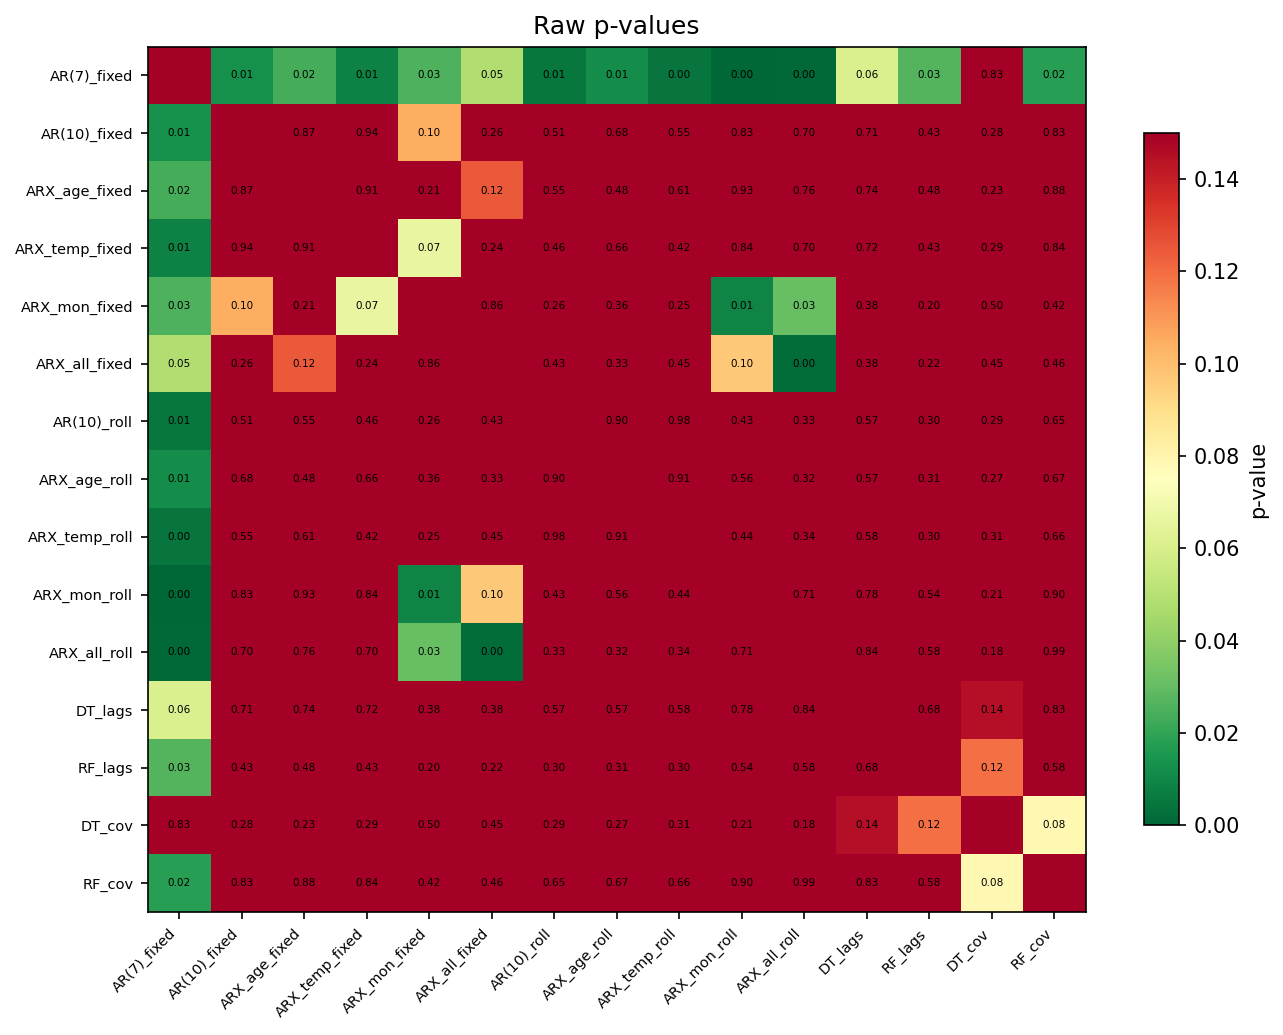

In [28]:
# ============================================================
# 12b-ii. Heatmap: Raw p-values
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7), dpi=150)
im = ax.imshow(dm_pvals.values.astype(float), cmap="RdYlGn_r", vmin=0, vmax=0.15, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)
ax.set_xticks(range(n_m)); ax.set_xticklabels(model_cols_dm, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_m)); ax.set_yticklabels(model_cols_dm, fontsize=7)
ax.set_title("Raw p-values")
for i in range(n_m):
    for j in range(n_m):
        if i == j: continue
        ax.text(j, i, f"{dm_pvals.iloc[i,j]:.2f}", ha="center", va="center", fontsize=5)
plt.tight_layout(); plt.savefig("fig_dm_raw_pvals.png", bbox_inches="tight"); plt.show()


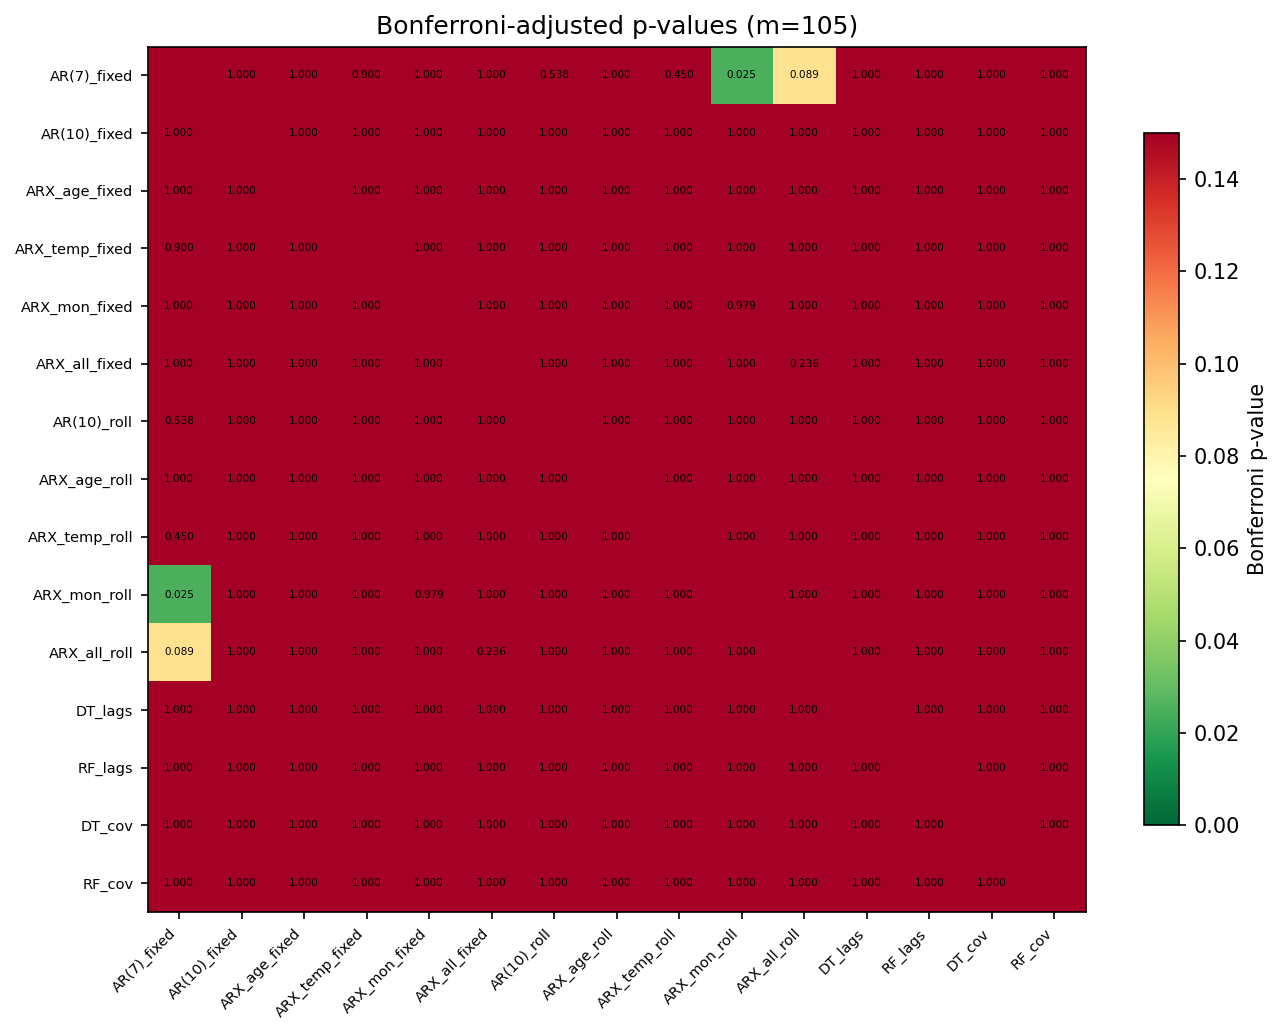

In [29]:
# ============================================================
# 12b-iii. Heatmap: Bonferroni-adjusted p-values
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7), dpi=150)
im = ax.imshow(dm_pvals_bonf.values.astype(float), cmap="RdYlGn_r", vmin=0, vmax=0.15, aspect="auto")
plt.colorbar(im, ax=ax, label="Bonferroni p-value", shrink=0.8)
ax.set_xticks(range(n_m)); ax.set_xticklabels(model_cols_dm, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_m)); ax.set_yticklabels(model_cols_dm, fontsize=7)
ax.set_title(f"Bonferroni-adjusted p-values (m={n_tests})")
for i in range(n_m):
    for j in range(n_m):
        if i == j: continue
        ax.text(j, i, f"{dm_pvals_bonf.iloc[i,j]:.3f}", ha="center", va="center", fontsize=5)
plt.tight_layout(); plt.savefig("fig_dm_bonf_pvals.png", bbox_inches="tight"); plt.show()


In [30]:
# ============================================================
# 12c. Significant pairs (raw vs Bonferroni)
# ============================================================

sig_rows = []
for m1, m2 in itertools.combinations(model_cols_dm, 2):
    p_raw  = dm_pvals.loc[m1, m2]
    p_bonf = dm_pvals_bonf.loc[m1, m2]
    s      = dm_stats.loc[m1, m2]

    if p_raw < 0.10:
        sig_rows.append({
            "Model A": m1, "Model B": m2,
            "DM-Stat": round(s, 3),
            "p (raw)": round(p_raw, 4),
            "p (Bonf)": round(p_bonf, 4),
            "Survives Bonf (5%)": "Yes" if p_bonf < 0.05 else "No",
            "Better": m1 if s < 0 else m2,
        })

sig_df = pd.DataFrame(sig_rows).sort_values("p (raw)")

n_raw_05  = sum(1 for _, r in sig_df.iterrows() if r["p (raw)"] < 0.05)
n_bonf_05 = sum(1 for _, r in sig_df.iterrows() if r["p (Bonf)"] < 0.05)

print(f"Total pairwise tests: {n_tests}")
print(f"Significant at 5% (raw):        {n_raw_05}")
print(f"Significant at 5% (Bonferroni): {n_bonf_05}")
print(f"\n{'='*90}")
print(sig_df.to_string(index=False))

sig_df.to_csv("project3_dm_results.csv", index=False)
print("\nSaved: project3_dm_results.csv")

Total pairwise tests: 105
Significant at 5% (raw):        15
Significant at 5% (Bonferroni): 1

       Model A        Model B  DM-Stat  p (raw)  p (Bonf) Survives Bonf (5%)         Better
   AR(7)_fixed   ARX_mon_roll    3.708   0.0002    0.0247                Yes   ARX_mon_roll
   AR(7)_fixed   ARX_all_roll    3.361   0.0008    0.0887                 No   ARX_all_roll
 ARX_all_fixed   ARX_all_roll    3.074   0.0022    0.2356                 No   ARX_all_roll
   AR(7)_fixed  ARX_temp_roll    2.871   0.0043    0.4501                 No  ARX_temp_roll
   AR(7)_fixed    AR(10)_roll    2.813   0.0051    0.5383                 No    AR(10)_roll
   AR(7)_fixed ARX_temp_fixed    2.641   0.0086    0.9000                 No ARX_temp_fixed
 ARX_mon_fixed   ARX_mon_roll    2.611   0.0093    0.9795                 No   ARX_mon_roll
   AR(7)_fixed   ARX_age_roll    2.520   0.0121    1.0000                 No   ARX_age_roll
   AR(7)_fixed   AR(10)_fixed    2.487   0.0133    1.0000                 No

## 13. Error diagnostic plots

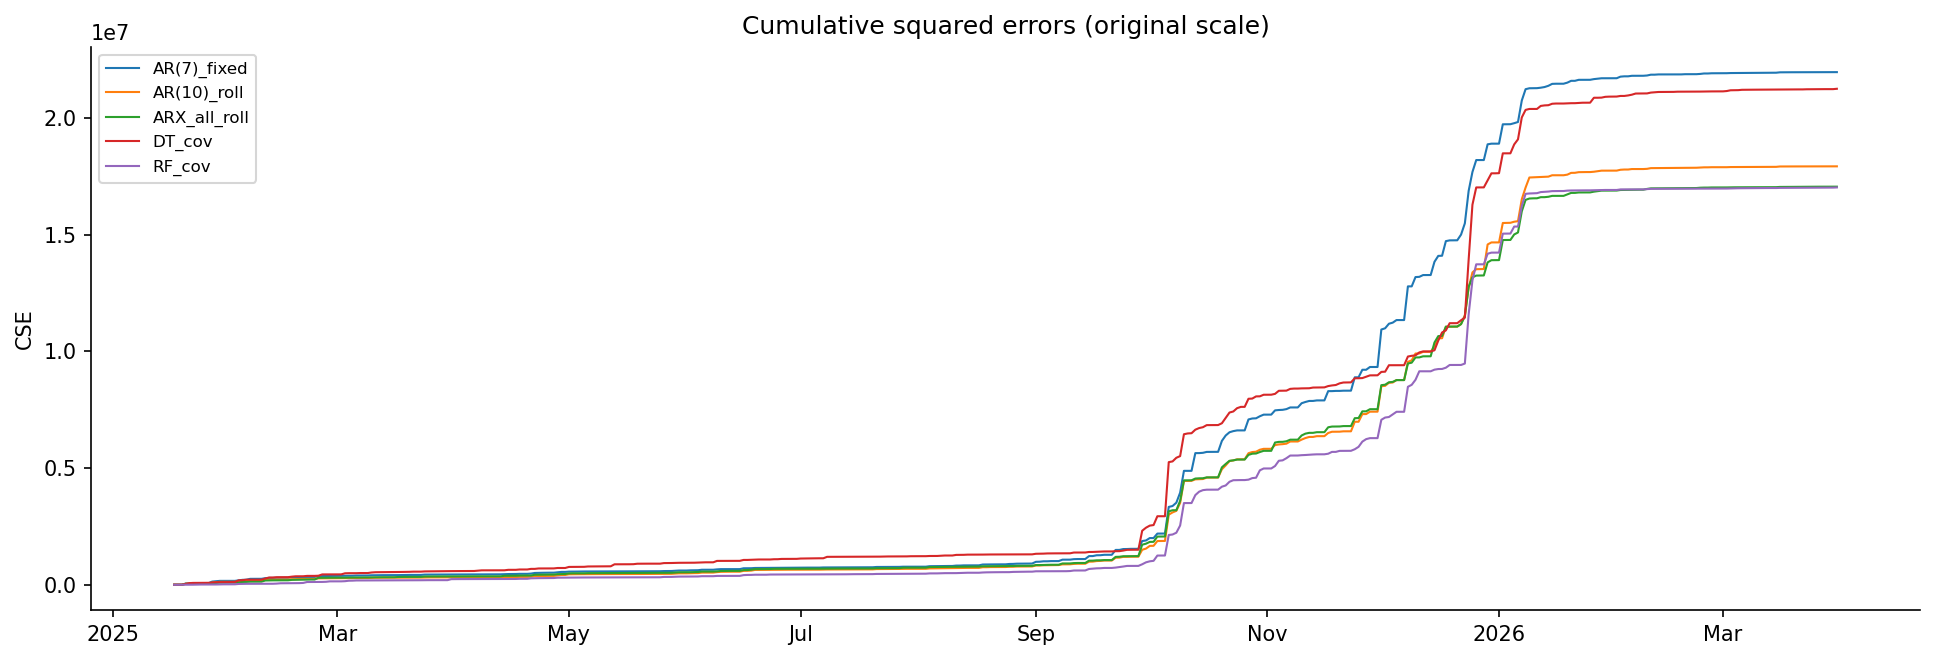

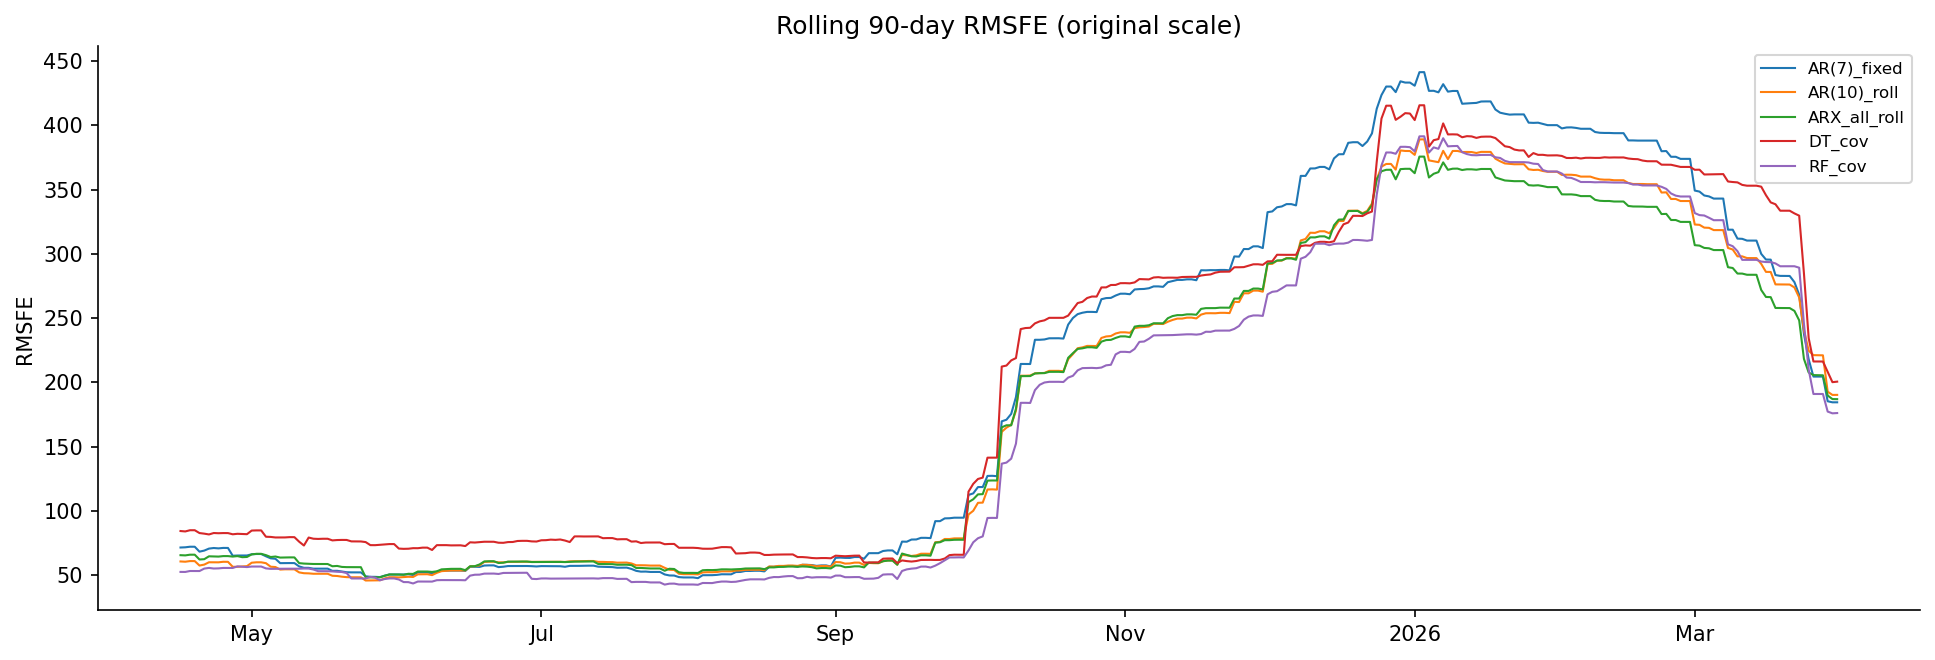

In [31]:
# Cumulative squared errors
fig, ax = plt.subplots(figsize=(13, 4.5))
for c in headline:
    mask = forecast_df_levels[c].notna() & forecast_df_levels["actual"].notna()
    cse = ((forecast_df_levels.loc[mask,"actual"] - forecast_df_levels.loc[mask,c])**2).cumsum()
    ax.plot(forecast_df_levels.index[mask], cse, lw=1.0, label=c)
ax.set_title("Cumulative squared errors (original scale)"); ax.set_ylabel("CSE")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig_cse.png", bbox_inches="tight"); plt.show()

# Rolling 90-day RMSFE
fig, ax = plt.subplots(figsize=(13, 4.5))
for c in headline:
    mask = forecast_df_levels[c].notna() & forecast_df_levels["actual"].notna()
    se = (forecast_df_levels.loc[mask,"actual"] - forecast_df_levels.loc[mask,c])**2
    roll = se.rolling(90).mean().pow(0.5)
    ax.plot(forecast_df_levels.index[mask], roll, lw=1.0, label=c)
ax.set_title("Rolling 90-day RMSFE (original scale)"); ax.set_ylabel("RMSFE")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig_rolling_rmsfe.png", bbox_inches="tight"); plt.show()